In [200]:
import pandas as pd

import numpy as np

import matplotlib.pyplot as plt

import seaborn as sb

from sklearn.metrics import accuracy_score

from sklearn.metrics import f1_score

from sklearn.metrics import confusion_matrix


In [201]:
Train_90_path = "../Data/Train_test/train_90.csv"

Train_120_path = "../Data/Train_test/train_120.csv"

Train_150_path = "../Data/Train_test/train_150.csv"


# test


Test_90_path = "../Data/churn_test_dataset_90.csv"

Test_120_path = "../Data/churn_test_dataset_120.csv"

Test_150_path = "../Data/churn_test_dataset_150.csv"

In [202]:
Data_train_90_df = pd.read_csv(Train_90_path)

Data_train_120_df = pd.read_csv(Train_120_path) 

Data_train_150_df = pd.read_csv(Train_150_path) 

Data_test_90_df = pd.read_csv(Test_90_path) 

Data_test_120_df = pd.read_csv(Test_120_path) 

Data_test_150_df = pd.read_csv(Test_150_path)  

-------
-------

## 90 days train_test dataset

In [203]:
state_count = Data_train_90_df["customer_state"].value_counts()

state_count

customer_state
SP    13327
RJ     4335
MG     3954
RS     1903
PR     1714
SC     1255
BA     1098
GO      702
ES      699
DF      693
PE      544
CE      435
PA      340
MT      319
MA      255
MS      238
PB      186
PI      179
RN      171
AL      127
SE      104
TO       83
RO       83
AM       43
AC       32
AP       26
RR       10
Name: count, dtype: int64

In [204]:
# Income
HIGH_INCOME = ["SP", "RJ", "AM", "SE"]
MID_INCOME = ["PI", "PB", "MS", "ES", "BA", "AL", "PE", "RN", "CE"]
LOW_INCOME = ["RR", "RO", "MT", "GO", "TO", "RS", "SC", "PR", "MA", "MG", "AC", "PA", "AP", "DF"]

prov_income_map = {
    **{i:"high" for i in HIGH_INCOME},
    **{i:"mid" for i in MID_INCOME},
    **{i:"low" for i in LOW_INCOME}
}
prov_income_map

{'SP': 'high',
 'RJ': 'high',
 'AM': 'high',
 'SE': 'high',
 'PI': 'mid',
 'PB': 'mid',
 'MS': 'mid',
 'ES': 'mid',
 'BA': 'mid',
 'AL': 'mid',
 'PE': 'mid',
 'RN': 'mid',
 'CE': 'mid',
 'RR': 'low',
 'RO': 'low',
 'MT': 'low',
 'GO': 'low',
 'TO': 'low',
 'RS': 'low',
 'SC': 'low',
 'PR': 'low',
 'MA': 'low',
 'MG': 'low',
 'AC': 'low',
 'PA': 'low',
 'AP': 'low',
 'DF': 'low'}

In [205]:
Data_train_90_df["state_income_level"] = Data_train_90_df.customer_state.map(prov_income_map)

Data_train_90_df["state_income_level_high"] = (Data_train_90_df["state_income_level"] == "high").astype(int)
Data_train_90_df["state_income_level_mid"] = (Data_train_90_df["state_income_level"] == "mid").astype(int)
Data_train_90_df["state_income_level_low"] = (Data_train_90_df["state_income_level"] == "low").astype(int)

Data_train_90_df

,customer_unique_id,price,freight_ratio,payment_value,dates_diff,review_score,customer_city,customer_state,order_status,payment_sequential,payment_type,payment_installments,product_cat,churn_90,state_income_level,state_income_level_high,state_income_level_mid,state_income_level_low
0,00115fc7123b5310cf6d3a3aa932699e,59.99,0.268711,76.11,-33.0,4.0,brasilia,DF,delivered,1.0,credit_card,1.0,sports_leisure,0,low,0,0,1
1,002b4cd83fabaffaa475f78ea5ef3e08,49.90,0.290982,64.42,-28.0,2.0,sao sebastiao do paraiso,MG,delivered,1.0,credit_card,1.0,fashion,0,low,0,0,1
2,0087eede471173af78d789df249c3a45,126.99,0.189936,151.11,-19.0,5.0,porto alegre,RS,delivered,1.0,boleto,1.0,miscellaneous,0,low,0,0,1
3,008f3d5f45a11059239a5c452cd00006,309.90,0.086028,336.56,-28.0,5.0,sao pedro da agua branca,MA,delivered,1.0,boleto,1.0,beauty,0,low,0,0,1
4,012b8001e47392df808a454083a74b74,65.60,0.497793,197.68,-28.0,5.0,capitao eneas,MG,delivered,1.0,credit_card,1.0,sports_leisure,0,low,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32850,ffe9e41fbd14db4a7361347c56af5447,199.00,0.109950,220.88,-9.0,5.0,vila velha,ES,delivered,1.0,credit_card,2.0,beauty,0,mid,0,1,0
32851,fff7219c86179ca6441b8f37823ba3d3,245.80,0.081367,531.60,-12.0,4.0,cachoeiras de macacu,RJ,delivered,1.0,debit_card,1.0,household,0,high,1,0,0
32852,fffb09418989a0dbff854a28163e47c6,58.00,0.261379,73.16,-23.0,5.0,veranopolis,RS,delivered,1.0,boleto,1.0,beauty,0,low,0,0,1
32853,fffbf87b7a1a6fa8b03f081c5f51a201,149.00,0.122953,167.32,-14.0,5.0,fortaleza,CE,delivered,1.0,credit_card,2.0,unknown,0,mid,0,1,0


In [206]:


Data_train_90_df["high_review_score"] = (Data_train_90_df["review_score"]>= 4).astype(int)
Data_train_90_df["medium_review_score"] = ((Data_train_90_df["review_score"]< 4) & (Data_train_90_df["review_score"]>= 2)).astype(int)
Data_train_90_df["low_review_score"] = (Data_train_90_df["review_score"]< 2).astype(int)

Data_train_90_df


,customer_unique_id,price,freight_ratio,payment_value,dates_diff,review_score,customer_city,customer_state,order_status,payment_sequential,...,payment_installments,product_cat,churn_90,state_income_level,state_income_level_high,state_income_level_mid,state_income_level_low,high_review_score,medium_review_score,low_review_score
0,00115fc7123b5310cf6d3a3aa932699e,59.99,0.268711,76.11,-33.0,4.0,brasilia,DF,delivered,1.0,...,1.0,sports_leisure,0,low,0,0,1,1,0,0
1,002b4cd83fabaffaa475f78ea5ef3e08,49.90,0.290982,64.42,-28.0,2.0,sao sebastiao do paraiso,MG,delivered,1.0,...,1.0,fashion,0,low,0,0,1,0,1,0
2,0087eede471173af78d789df249c3a45,126.99,0.189936,151.11,-19.0,5.0,porto alegre,RS,delivered,1.0,...,1.0,miscellaneous,0,low,0,0,1,1,0,0
3,008f3d5f45a11059239a5c452cd00006,309.90,0.086028,336.56,-28.0,5.0,sao pedro da agua branca,MA,delivered,1.0,...,1.0,beauty,0,low,0,0,1,1,0,0
4,012b8001e47392df808a454083a74b74,65.60,0.497793,197.68,-28.0,5.0,capitao eneas,MG,delivered,1.0,...,1.0,sports_leisure,0,low,0,0,1,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32850,ffe9e41fbd14db4a7361347c56af5447,199.00,0.109950,220.88,-9.0,5.0,vila velha,ES,delivered,1.0,...,2.0,beauty,0,mid,0,1,0,1,0,0
32851,fff7219c86179ca6441b8f37823ba3d3,245.80,0.081367,531.60,-12.0,4.0,cachoeiras de macacu,RJ,delivered,1.0,...,1.0,household,0,high,1,0,0,1,0,0
32852,fffb09418989a0dbff854a28163e47c6,58.00,0.261379,73.16,-23.0,5.0,veranopolis,RS,delivered,1.0,...,1.0,beauty,0,low,0,0,1,1,0,0
32853,fffbf87b7a1a6fa8b03f081c5f51a201,149.00,0.122953,167.32,-14.0,5.0,fortaleza,CE,delivered,1.0,...,2.0,unknown,0,mid,0,1,0,1,0,0


In [207]:
Data_train_90_df["delay"] = (Data_train_90_df["dates_diff"]>0).astype(int)

Data_train_90_df["delay"]

0        0
1        0
2        0
3        0
4        0
        ..
32850    0
32851    0
32852    0
32853    0
32854    0
Name: delay, Length: 32855, dtype: int64

In [208]:
Data_train_90_df["high_payment_value"] = (Data_train_90_df["payment_value"]>172.73).astype(int)

Data_train_90_df["high_payment_value"]

0        0
1        0
2        0
3        1
4        1
        ..
32850    1
32851    1
32852    0
32853    0
32854    0
Name: high_payment_value, Length: 32855, dtype: int64

In [209]:
# One hot encoding for freight_price
Data_train_90_df["expensive_freight"] = (Data_train_90_df["freight_ratio"]>0.15).astype(int)

Data_train_90_df["expensive_freight"]

0        1
1        1
2        1
3        0
4        1
        ..
32850    0
32851    0
32852    1
32853    0
32854    1
Name: expensive_freight, Length: 32855, dtype: int64

In [210]:
# One hot encoding for price

Data_train_90_df["is_high_price"] = (Data_train_90_df["price"]>120.64).astype(int)

Data_train_90_df["is_high_price"]

0        0
1        0
2        1
3        1
4        0
        ..
32850    1
32851    1
32852    0
32853    1
32854    0
Name: is_high_price, Length: 32855, dtype: int64

In [211]:
Data_train_90_df["beyond_one year"] = (Data_train_90_df["payment_installments"] > 12.0).astype(int)

Data_train_90_df["beyond_one year"]

0        0
1        0
2        0
3        0
4        0
        ..
32850    0
32851    0
32852    0
32853    0
32854    0
Name: beyond_one year, Length: 32855, dtype: int64

In [212]:
Data_train_90_df["multiple_payment_methods"] = (Data_train_90_df["payment_sequential"] > 2.0).astype(int)

Data_train_90_df["multiple_payment_methods"]

0        0
1        0
2        0
3        0
4        0
        ..
32850    0
32851    0
32852    0
32853    0
32854    0
Name: multiple_payment_methods, Length: 32855, dtype: int64

In [213]:
from sklearn.compose import ColumnTransformer

from sklearn.preprocessing import OneHotEncoder

In [214]:
# Create one hot encoding for all non-int features  Logprices?

target_features = ["order_status", "payment_type", "product_cat"]

col_trans = ColumnTransformer(
    transformers=[("cat", OneHotEncoder(sparse_output= False, drop="first", handle_unknown="ignore"), target_features)], remainder="passthrough"
)
col_trans.fit(Data_train_90_df)

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'passthrough'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_name``. e.g. 

In [215]:
# fit and transform the dataset

encoded_array = col_trans.transform(Data_train_90_df)

In [216]:
feature_names = col_trans.get_feature_names_out(Data_train_90_df.columns)
encoded_90_df = pd.DataFrame(encoded_array, columns= feature_names)

encoded_90_df

,cat__order_status_canceled,cat__order_status_delivered,cat__order_status_invoiced,cat__order_status_processing,cat__order_status_shipped,cat__payment_type_credit_card,cat__payment_type_debit_card,cat__payment_type_voucher,cat__product_cat_babies,cat__product_cat_beauty,...,remainder__state_income_level_low,remainder__high_review_score,remainder__medium_review_score,remainder__low_review_score,remainder__delay,remainder__high_payment_value,remainder__expensive_freight,remainder__is_high_price,remainder__beyond_one year,remainder__multiple_payment_methods
0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,1,1,0,0,0,0,1,0,0,0
1,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,1,0,1,0,0,0,1,0,0,0
2,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1,1,0,0,0,0,1,1,0,0
3,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,...,1,1,0,0,0,1,0,1,0,0
4,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,1,1,0,0,0,1,1,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32850,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,...,0,1,0,0,0,1,0,1,0,0
32851,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0,1,0,0,0,1,0,1,0,0
32852,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,...,1,1,0,0,0,0,1,0,0,0
32853,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,0,1,0,0,0,0,0,1,0,0


In [217]:
encoded_90_df.columns = encoded_90_df.columns.str.replace('remainder__', '')

encoded_90_df

,cat__order_status_canceled,cat__order_status_delivered,cat__order_status_invoiced,cat__order_status_processing,cat__order_status_shipped,cat__payment_type_credit_card,cat__payment_type_debit_card,cat__payment_type_voucher,cat__product_cat_babies,cat__product_cat_beauty,...,state_income_level_low,high_review_score,medium_review_score,low_review_score,delay,high_payment_value,expensive_freight,is_high_price,beyond_one year,multiple_payment_methods
0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,1,1,0,0,0,0,1,0,0,0
1,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,1,0,1,0,0,0,1,0,0,0
2,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1,1,0,0,0,0,1,1,0,0
3,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,...,1,1,0,0,0,1,0,1,0,0
4,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,1,1,0,0,0,1,1,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32850,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,...,0,1,0,0,0,1,0,1,0,0
32851,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0,1,0,0,0,1,0,1,0,0
32852,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,...,1,1,0,0,0,0,1,0,0,0
32853,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,0,1,0,0,0,0,0,1,0,0


beyond one tear= the payment takes more than one year

-----

# Test dataset

In [218]:
Data_test_90_df

,customer_unique_id,price,freight_ratio,payment_value,dates_diff,review_score,customer_city,customer_state,order_status,payment_sequential,payment_type,payment_installments,product_cat,churn_90
0,0004bd2a26a76fe21f786e4fbd80607f,154.00,0.084286,166.98,-12.0,4.0,sao paulo,SP,delivered,1.0,credit_card,8.0,miscellaneous,0
1,00053a61a98854899e70ed204dd4bafe,382.00,0.097330,838.36,-10.0,1.0,curitiba,PR,delivered,1.0,credit_card,3.0,sports_leisure,0
2,0005ef4cd20d2893f0d9fbd94d3c0d97,104.90,0.236988,129.76,31.0,1.0,sao luis,MA,delivered,1.0,credit_card,4.0,sports_leisure,0
3,00090324bbad0e9342388303bb71ba0a,49.95,0.274474,63.66,-8.0,5.0,campinas,SP,delivered,1.0,credit_card,3.0,household,0
4,0010fb34b966d44409382af9e8fd5b77,49.95,0.237237,61.80,2.0,4.0,sao paulo,SP,delivered,1.0,credit_card,6.0,household,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20563,ffe6efca3c7e6a06bad0a6a883280a93,213.90,0.060776,226.90,-9.0,4.0,praia grande,SP,delivered,1.0,credit_card,2.0,beauty,0
20564,ffe9e41fbd14db4a7361347c56af5447,199.00,0.109950,220.88,-9.0,5.0,vila velha,ES,delivered,1.0,credit_card,2.0,beauty,0
20565,ffec10ad4229ba46818560e1c8b40a68,120.00,0.131000,135.72,-10.0,5.0,viana,ES,delivered,1.0,credit_card,3.0,sports_leisure,0
20566,fff1bdd5c5e37ca79dd74deeb91aa5b6,134.90,0.282283,172.98,32.0,1.0,araguaina,TO,delivered,2.0,debit_card,1.0,entertainment,0


In [219]:
Data_test_90_df["state_income_level"] = Data_test_90_df.customer_state.map(prov_income_map)

Data_test_90_df["state_income_level_high"] = (Data_test_90_df["state_income_level"] == "high").astype(int)
Data_test_90_df["state_income_level_mid"] = (Data_test_90_df["state_income_level"] == "mid").astype(int)
Data_test_90_df["state_income_level_low"] = (Data_test_90_df["state_income_level"] == "low").astype(int)

Data_test_90_df 

,customer_unique_id,price,freight_ratio,payment_value,dates_diff,review_score,customer_city,customer_state,order_status,payment_sequential,payment_type,payment_installments,product_cat,churn_90,state_income_level,state_income_level_high,state_income_level_mid,state_income_level_low
0,0004bd2a26a76fe21f786e4fbd80607f,154.00,0.084286,166.98,-12.0,4.0,sao paulo,SP,delivered,1.0,credit_card,8.0,miscellaneous,0,high,1,0,0
1,00053a61a98854899e70ed204dd4bafe,382.00,0.097330,838.36,-10.0,1.0,curitiba,PR,delivered,1.0,credit_card,3.0,sports_leisure,0,low,0,0,1
2,0005ef4cd20d2893f0d9fbd94d3c0d97,104.90,0.236988,129.76,31.0,1.0,sao luis,MA,delivered,1.0,credit_card,4.0,sports_leisure,0,low,0,0,1
3,00090324bbad0e9342388303bb71ba0a,49.95,0.274474,63.66,-8.0,5.0,campinas,SP,delivered,1.0,credit_card,3.0,household,0,high,1,0,0
4,0010fb34b966d44409382af9e8fd5b77,49.95,0.237237,61.80,2.0,4.0,sao paulo,SP,delivered,1.0,credit_card,6.0,household,0,high,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20563,ffe6efca3c7e6a06bad0a6a883280a93,213.90,0.060776,226.90,-9.0,4.0,praia grande,SP,delivered,1.0,credit_card,2.0,beauty,0,high,1,0,0
20564,ffe9e41fbd14db4a7361347c56af5447,199.00,0.109950,220.88,-9.0,5.0,vila velha,ES,delivered,1.0,credit_card,2.0,beauty,0,mid,0,1,0
20565,ffec10ad4229ba46818560e1c8b40a68,120.00,0.131000,135.72,-10.0,5.0,viana,ES,delivered,1.0,credit_card,3.0,sports_leisure,0,mid,0,1,0
20566,fff1bdd5c5e37ca79dd74deeb91aa5b6,134.90,0.282283,172.98,32.0,1.0,araguaina,TO,delivered,2.0,debit_card,1.0,entertainment,0,low,0,0,1


In [220]:
Data_test_90_df["high_review_score"] = (Data_test_90_df["review_score"]>= 4).astype(int)
Data_test_90_df["medium_review_score"] = ((Data_test_90_df["review_score"]< 4) & (Data_test_90_df["review_score"]>= 2)).astype(int)
Data_test_90_df["low_review_score"] = (Data_test_90_df["review_score"]< 2).astype(int)

Data_test_90_df

,customer_unique_id,price,freight_ratio,payment_value,dates_diff,review_score,customer_city,customer_state,order_status,payment_sequential,...,payment_installments,product_cat,churn_90,state_income_level,state_income_level_high,state_income_level_mid,state_income_level_low,high_review_score,medium_review_score,low_review_score
0,0004bd2a26a76fe21f786e4fbd80607f,154.00,0.084286,166.98,-12.0,4.0,sao paulo,SP,delivered,1.0,...,8.0,miscellaneous,0,high,1,0,0,1,0,0
1,00053a61a98854899e70ed204dd4bafe,382.00,0.097330,838.36,-10.0,1.0,curitiba,PR,delivered,1.0,...,3.0,sports_leisure,0,low,0,0,1,0,0,1
2,0005ef4cd20d2893f0d9fbd94d3c0d97,104.90,0.236988,129.76,31.0,1.0,sao luis,MA,delivered,1.0,...,4.0,sports_leisure,0,low,0,0,1,0,0,1
3,00090324bbad0e9342388303bb71ba0a,49.95,0.274474,63.66,-8.0,5.0,campinas,SP,delivered,1.0,...,3.0,household,0,high,1,0,0,1,0,0
4,0010fb34b966d44409382af9e8fd5b77,49.95,0.237237,61.80,2.0,4.0,sao paulo,SP,delivered,1.0,...,6.0,household,0,high,1,0,0,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20563,ffe6efca3c7e6a06bad0a6a883280a93,213.90,0.060776,226.90,-9.0,4.0,praia grande,SP,delivered,1.0,...,2.0,beauty,0,high,1,0,0,1,0,0
20564,ffe9e41fbd14db4a7361347c56af5447,199.00,0.109950,220.88,-9.0,5.0,vila velha,ES,delivered,1.0,...,2.0,beauty,0,mid,0,1,0,1,0,0
20565,ffec10ad4229ba46818560e1c8b40a68,120.00,0.131000,135.72,-10.0,5.0,viana,ES,delivered,1.0,...,3.0,sports_leisure,0,mid,0,1,0,1,0,0
20566,fff1bdd5c5e37ca79dd74deeb91aa5b6,134.90,0.282283,172.98,32.0,1.0,araguaina,TO,delivered,2.0,...,1.0,entertainment,0,low,0,0,1,0,0,1


In [221]:
Data_test_90_df["delay"] = (Data_test_90_df["dates_diff"]>0).astype(int)

Data_test_90_df["delay"]

0        0
1        0
2        1
3        0
4        1
        ..
20563    0
20564    0
20565    0
20566    1
20567    0
Name: delay, Length: 20568, dtype: int64

In [222]:
Data_test_90_df["high_payment_value"] = (Data_test_90_df["payment_value"]>172.73).astype(int)

Data_test_90_df["high_payment_value"]

0        0
1        1
2        0
3        0
4        0
        ..
20563    1
20564    1
20565    0
20566    1
20567    1
Name: high_payment_value, Length: 20568, dtype: int64

In [223]:
Data_test_90_df["expensive_freight"] = (Data_test_90_df["freight_ratio"]>0.15).astype(int)

Data_test_90_df["expensive_freight"]

0        0
1        0
2        1
3        1
4        1
        ..
20563    0
20564    0
20565    0
20566    1
20567    0
Name: expensive_freight, Length: 20568, dtype: int64

In [224]:
Data_test_90_df["is_high_price"] = (Data_test_90_df["price"]>120.64).astype(int)

Data_test_90_df["is_high_price"]

0        1
1        1
2        0
3        0
4        0
        ..
20563    1
20564    1
20565    0
20566    1
20567    1
Name: is_high_price, Length: 20568, dtype: int64

In [225]:
Data_test_90_df["beyond_one year"] = (Data_test_90_df["payment_installments"] > 12.0).astype(int)

Data_test_90_df["beyond_one year"]

0        0
1        0
2        0
3        0
4        0
        ..
20563    0
20564    0
20565    0
20566    0
20567    0
Name: beyond_one year, Length: 20568, dtype: int64

In [226]:
Data_test_90_df["multiple_payment_methods"] = (Data_test_90_df["payment_sequential"] > 2.0).astype(int)

Data_test_90_df["multiple_payment_methods"]

0        0
1        0
2        0
3        0
4        0
        ..
20563    0
20564    0
20565    0
20566    0
20567    0
Name: multiple_payment_methods, Length: 20568, dtype: int64

In [227]:
Data_train_90_df["order_status"].value_counts()

order_status
delivered     32081
shipped         358
canceled        176
processing      153
invoiced         86
approved          1
Name: count, dtype: int64

In [228]:
Data_test_90_df["order_status"].value_counts()

order_status
delivered     20098
shipped         278
canceled        123
invoiced         43
processing       26
Name: count, dtype: int64

In [229]:
target_features = ["order_status", "payment_type", "product_cat"]



In [230]:
encoded_array_test = col_trans.transform(Data_test_90_df)

In [231]:
Data_test_90_df.columns

Index(['customer_unique_id', 'price', 'freight_ratio', 'payment_value',
       'dates_diff', 'review_score', 'customer_city', 'customer_state',
       'order_status', 'payment_sequential', 'payment_type',
       'payment_installments', 'product_cat', 'churn_90', 'state_income_level',
       'state_income_level_high', 'state_income_level_mid',
       'state_income_level_low', 'high_review_score', 'medium_review_score',
       'low_review_score', 'delay', 'high_payment_value', 'expensive_freight',
       'is_high_price', 'beyond_one year', 'multiple_payment_methods'],
      dtype='str')

In [232]:
Data_test_90_df.columns

Index(['customer_unique_id', 'price', 'freight_ratio', 'payment_value',
       'dates_diff', 'review_score', 'customer_city', 'customer_state',
       'order_status', 'payment_sequential', 'payment_type',
       'payment_installments', 'product_cat', 'churn_90', 'state_income_level',
       'state_income_level_high', 'state_income_level_mid',
       'state_income_level_low', 'high_review_score', 'medium_review_score',
       'low_review_score', 'delay', 'high_payment_value', 'expensive_freight',
       'is_high_price', 'beyond_one year', 'multiple_payment_methods'],
      dtype='str')

In [233]:
encoded_90_test_df = pd.DataFrame(encoded_array, columns= col_trans.get_feature_names_out(Data_test_90_df.columns))

encoded_90_test_df

,cat__order_status_canceled,cat__order_status_delivered,cat__order_status_invoiced,cat__order_status_processing,cat__order_status_shipped,cat__payment_type_credit_card,cat__payment_type_debit_card,cat__payment_type_voucher,cat__product_cat_babies,cat__product_cat_beauty,...,remainder__state_income_level_low,remainder__high_review_score,remainder__medium_review_score,remainder__low_review_score,remainder__delay,remainder__high_payment_value,remainder__expensive_freight,remainder__is_high_price,remainder__beyond_one year,remainder__multiple_payment_methods
0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,1,1,0,0,0,0,1,0,0,0
1,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,1,0,1,0,0,0,1,0,0,0
2,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1,1,0,0,0,0,1,1,0,0
3,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,...,1,1,0,0,0,1,0,1,0,0
4,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,1,1,0,0,0,1,1,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32850,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,...,0,1,0,0,0,1,0,1,0,0
32851,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0,1,0,0,0,1,0,1,0,0
32852,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,...,1,1,0,0,0,0,1,0,0,0
32853,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,0,1,0,0,0,0,0,1,0,0


In [234]:
encoded_90_test_df.columns = encoded_90_test_df.columns.str.replace('remainder__', '')

encoded_90_test_df

,cat__order_status_canceled,cat__order_status_delivered,cat__order_status_invoiced,cat__order_status_processing,cat__order_status_shipped,cat__payment_type_credit_card,cat__payment_type_debit_card,cat__payment_type_voucher,cat__product_cat_babies,cat__product_cat_beauty,...,state_income_level_low,high_review_score,medium_review_score,low_review_score,delay,high_payment_value,expensive_freight,is_high_price,beyond_one year,multiple_payment_methods
0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,1,1,0,0,0,0,1,0,0,0
1,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,1,0,1,0,0,0,1,0,0,0
2,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1,1,0,0,0,0,1,1,0,0
3,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,...,1,1,0,0,0,1,0,1,0,0
4,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,1,1,0,0,0,1,1,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32850,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,...,0,1,0,0,0,1,0,1,0,0
32851,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0,1,0,0,0,1,0,1,0,0
32852,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,...,1,1,0,0,0,0,1,0,0,0
32853,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,0,1,0,0,0,0,0,1,0,0


In [235]:
Data_test_90_df["churn_90"].value_counts()

churn_90
0    20385
1      183
Name: count, dtype: int64

--------

In [236]:
encoded_90_df["customer_unique_id"]

0        00115fc7123b5310cf6d3a3aa932699e
1        002b4cd83fabaffaa475f78ea5ef3e08
2        0087eede471173af78d789df249c3a45
3        008f3d5f45a11059239a5c452cd00006
4        012b8001e47392df808a454083a74b74
                       ...               
32850    ffe9e41fbd14db4a7361347c56af5447
32851    fff7219c86179ca6441b8f37823ba3d3
32852    fffb09418989a0dbff854a28163e47c6
32853    fffbf87b7a1a6fa8b03f081c5f51a201
32854    fffea47cd6d3cc0a88bd621562a9d061
Name: customer_unique_id, Length: 32855, dtype: str

# Train test split

In [237]:
X_train = encoded_90_df.drop(columns = ['churn_90', "customer_unique_id", "customer_city", "customer_state",	"payment_sequential", "payment_installments",	"state_income_level", "price", "freight_ratio", "payment_value", "dates_diff",	"review_score"])

y_train = encoded_90_df['churn_90'].fillna(0).astype(int)

In [238]:
X_valtest = encoded_90_test_df.drop(columns = ['churn_90', "customer_unique_id", "customer_city", "customer_state",	"payment_sequential", "payment_installments",	"state_income_level", "price", "freight_ratio", "payment_value", "dates_diff",	"review_score"])

y_valtest = encoded_90_test_df['churn_90'].fillna(0).astype(int)

In [239]:
encoded_90_df.dtypes.value_counts()

object    43
str        4
Name: count, dtype: int64

In [ ]:
X_train = X_train.astype(int)


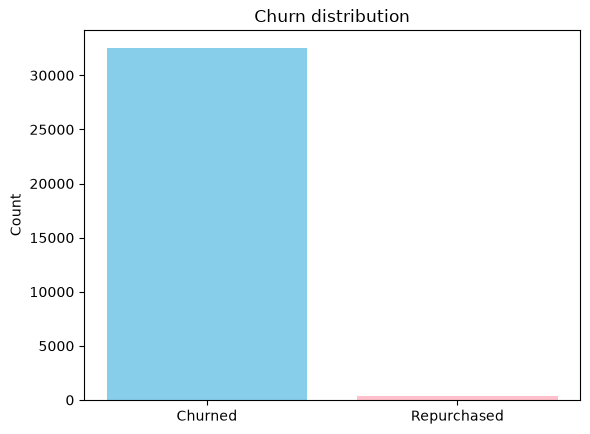

In [241]:

plt.bar(y_train.value_counts().index, y_train.value_counts().values, color=['skyblue','pink'])
plt.xticks([0,1], ["Churned", "Repurchased"])
plt.ylabel("Count")
plt.title("Churn distribution")
plt.show()

In [242]:
y_train

0        0
1        0
2        0
3        0
4        0
        ..
32850    0
32851    0
32852    0
32853    0
32854    0
Name: churn_90, Length: 32855, dtype: int64

In [283]:
from sklearn.model_selection import train_test_split

X_val, X_test, y_val, y_test  =  train_test_split(X_valtest, y_valtest, test_size= 0.5, random_state = 42)
X_val = X_val.astype(int)
X_test = X_test.astype(int)

In [244]:
print(X_train.shape)
print(X_valtest.shape)

(32855, 35)
(32855, 35)


-----

## Logistic Regression

In [245]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression( random_state= 42)


# fit the model
lr.fit(X_train, y_train)

,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",42
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solve

In [246]:
pd.DataFrame(list(zip(X_train.columns, lr.coef_[0])), columns= ["Feature_name", "Coefficient"])

,Feature_name,Coefficient
0,cat__order_status_canceled,0.100867
1,cat__order_status_delivered,-0.240230
2,cat__order_status_invoiced,-0.140141
3,cat__order_status_processing,-0.780638
4,cat__order_status_shipped,-1.131702
5,cat__payment_type_credit_card,-0.004547
6,cat__payment_type_debit_card,-0.074956
7,cat__payment_type_voucher,0.119047
8,cat__product_cat_babies,-0.308277
9,cat__product_cat_beauty,0.025367


In [247]:
lr.coef_

array([[ 0.10086734, -0.24023041, -0.14014071, -0.78063776, -1.13170236,
        -0.00454706, -0.07495565,  0.11904678, -0.30827669,  0.02536749,
        -0.82216784, -0.54061502, -0.08924199, -0.06580357, -0.18689936,
         0.24646224, -0.42645364,  0.29129309, -0.03560753, -0.05310973,
         0.61052541,  0.23689592, -0.37870307, -0.58180409, -0.93806438,
        -0.67720684, -0.67461582, -0.57925149, -0.943208  , -0.02113871,
         0.22736162,  0.12526136,  0.02488565,  0.15843631,  0.88840135]])

In [248]:
import statsmodels.api as stm

model_stm = stm.Logit(y_train, X_train).fit()

print(model_stm.summary())

         Current function value: 0.054550
         Iterations: 35


c:\Users\Hallen\anaconda3\envs\silv_env\Lib\site-packages\statsmodels\discrete\discrete_model.py:268: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  mlefit = super().fit(


                           Logit Regression Results                           
Dep. Variable:               churn_90   No. Observations:                32855
Model:                          Logit   Df Residuals:                    32820
Method:                           MLE   Df Model:                           34
Date:                Sun, 13 Sep 2026   Pseudo R-squ.:                 0.01220
Time:                        13:39:27   Log-Likelihood:                -1792.2
converged:                      False   LL-Null:                       -1814.4
Covariance Type:            nonrobust   LLR p-value:                    0.1119
                                             coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------------------------
cat__order_status_canceled                10.1001   1357.458      0.007      0.994   -2650.469    2670.669
cat__order_status_delivered                9.29

In [249]:
ds_list = [
    ("Train", X_train, y_train),
    ("Val", X_val, y_val),
    ("Test", X_test, y_test)
]

for ds_name, ds_x, ds_y in ds_list:
    ds_y_pred = lr.predict(ds_x)

    print(ds_name)
    print('Model F1 score with gini index: {0:0.4f}'. format(f1_score(ds_y, ds_y_pred)))
    print('Model accuracy score with gini index: {0:0.4f}'. format(accuracy_score(ds_y, ds_y_pred)))

    cm = confusion_matrix(ds_y, ds_y_pred)
    print(cm)
    print()


Train
Model F1 score with gini index: 0.0000
Model accuracy score with gini index: 0.9902
[[32532     0]
 [  323     0]]

Val
Model F1 score with gini index: 0.0000
Model accuracy score with gini index: 0.9906
[[16272     0]
 [  155     0]]

Test
Model F1 score with gini index: 0.0000
Model accuracy score with gini index: 0.9898
[[16260     0]
 [  168     0]]



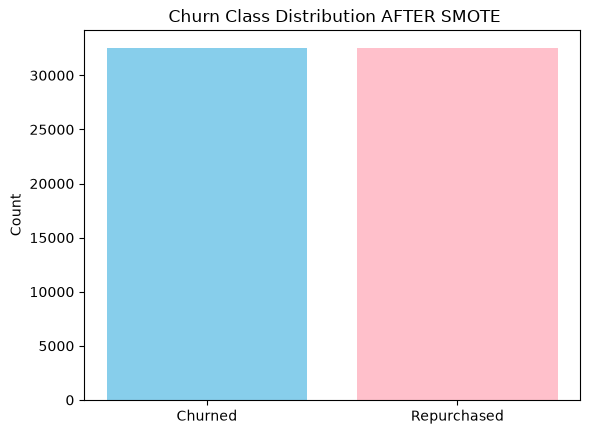

In [250]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(sampling_strategy="minority", random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

plt.bar(y_train_sm.value_counts().index, y_train_sm.value_counts().values, 
        color=["skyblue","pink"])
plt.xticks([0,1], ["Churned", "Repurchased"])
plt.ylabel("Count")
plt.title(" Churn Class Distribution AFTER SMOTE")
plt.show()

After smote

In [251]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression( random_state= 42)


# fit the model
lr.fit(X_train_sm, y_train_sm)

,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",42
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solve

In [252]:
pd.DataFrame(list(zip(X_train.columns, lr.coef_[0])), columns= ["Feature_name", "Coefficient"])

,Feature_name,Coefficient
0,cat__order_status_canceled,-5.236182
1,cat__order_status_delivered,-2.967061
2,cat__order_status_invoiced,-4.437900
3,cat__order_status_processing,-5.467392
4,cat__order_status_shipped,-6.200416
5,cat__payment_type_credit_card,-0.071733
6,cat__payment_type_debit_card,-3.930710
7,cat__payment_type_voucher,-1.091252
8,cat__product_cat_babies,-4.885527
9,cat__product_cat_beauty,-2.687080


In [253]:
import statsmodels.api as stm

model_stm = stm.Logit(y_train, X_train).fit()

print(model_stm.summary())

         Current function value: 0.054550
         Iterations: 35


c:\Users\Hallen\anaconda3\envs\silv_env\Lib\site-packages\statsmodels\discrete\discrete_model.py:268: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  mlefit = super().fit(


                           Logit Regression Results                           
Dep. Variable:               churn_90   No. Observations:                32855
Model:                          Logit   Df Residuals:                    32820
Method:                           MLE   Df Model:                           34
Date:                Sun, 13 Sep 2026   Pseudo R-squ.:                 0.01220
Time:                        13:39:30   Log-Likelihood:                -1792.2
converged:                      False   LL-Null:                       -1814.4
Covariance Type:            nonrobust   LLR p-value:                    0.1119
                                             coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------------------------
cat__order_status_canceled                10.1001   1357.458      0.007      0.994   -2650.469    2670.669
cat__order_status_delivered                9.29

In [254]:


ds_list = [
    ("Train", X_train, y_train),
    ("Val", X_val, y_val),
    ("Test", X_test, y_test)
]

for ds_name, ds_x, ds_y in ds_list:
    ds_y_pred = lr.predict(ds_x)

    print(ds_name)
    print('Model F1 score with gini index: {0:0.4f}'. format(f1_score(ds_y, ds_y_pred)))
    print('Model accuracy score with gini index: {0:0.4f}'. format(accuracy_score(ds_y, ds_y_pred)))

    cm = confusion_matrix(ds_y, ds_y_pred)
    print(cm)
    print()

Train
Model F1 score with gini index: 0.0249
Model accuracy score with gini index: 0.7810
[[25568  6964]
 [  231    92]]

Val
Model F1 score with gini index: 0.0268
Model accuracy score with gini index: 0.7835
[[12822  3450]
 [  106    49]]

Test
Model F1 score with gini index: 0.0231
Model accuracy score with gini index: 0.7785
[[12746  3514]
 [  125    43]]



----

# Gini criterion

## Decision tree

In [255]:
from sklearn.tree import DecisionTreeClassifier

In [256]:
clf = DecisionTreeClassifier(criterion = "gini", max_depth = 5000, random_state= 42)


clf.fit(X_train, y_train)

,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",5000
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples 

In [257]:
X_train.columns

Index(['cat__order_status_canceled', 'cat__order_status_delivered',
       'cat__order_status_invoiced', 'cat__order_status_processing',
       'cat__order_status_shipped', 'cat__payment_type_credit_card',
       'cat__payment_type_debit_card', 'cat__payment_type_voucher',
       'cat__product_cat_babies', 'cat__product_cat_beauty',
       'cat__product_cat_books_media',
       'cat__product_cat_commercial_industrial',
       'cat__product_cat_construction', 'cat__product_cat_electronics',
       'cat__product_cat_entertainment', 'cat__product_cat_fashion',
       'cat__product_cat_food_drink', 'cat__product_cat_household',
       'cat__product_cat_miscellaneous', 'cat__product_cat_office',
       'cat__product_cat_pet_shop', 'cat__product_cat_sports_leisure',
       'cat__product_cat_unknown', 'state_income_level_high',
       'state_income_level_mid', 'state_income_level_low', 'high_review_score',
       'medium_review_score', 'low_review_score', 'delay',
       'high_payment_value',

In [258]:
X_test.columns

Index(['cat__order_status_canceled', 'cat__order_status_delivered',
       'cat__order_status_invoiced', 'cat__order_status_processing',
       'cat__order_status_shipped', 'cat__payment_type_credit_card',
       'cat__payment_type_debit_card', 'cat__payment_type_voucher',
       'cat__product_cat_babies', 'cat__product_cat_beauty',
       'cat__product_cat_books_media',
       'cat__product_cat_commercial_industrial',
       'cat__product_cat_construction', 'cat__product_cat_electronics',
       'cat__product_cat_entertainment', 'cat__product_cat_fashion',
       'cat__product_cat_food_drink', 'cat__product_cat_household',
       'cat__product_cat_miscellaneous', 'cat__product_cat_office',
       'cat__product_cat_pet_shop', 'cat__product_cat_sports_leisure',
       'cat__product_cat_unknown', 'state_income_level_high',
       'state_income_level_mid', 'state_income_level_low', 'high_review_score',
       'medium_review_score', 'low_review_score', 'delay',
       'high_payment_value',

In [259]:
#{0:0.4f} = f means float and you will have until 4 decimals

ds_list = [
    ("Train", X_train, y_train),
    ("Val", X_val, y_val),
    ("Test", X_test, y_test)
]

for ds_name, ds_x, ds_y in ds_list:
    ds_y_pred = clf.predict(ds_x)

    print(ds_name)
    print('Model F1 score with gini index: {0:0.4f}'. format(f1_score(ds_y, ds_y_pred)))
    print('Model accuracy score with gini index: {0:0.4f}'. format(accuracy_score(ds_y, ds_y_pred)))

    cm = confusion_matrix(ds_y, ds_y_pred)
    print(cm)
    print()


Train
Model F1 score with gini index: 0.1111
Model accuracy score with gini index: 0.9907
[[32532     0]
 [  304    19]]

Val
Model F1 score with gini index: 0.0864
Model accuracy score with gini index: 0.9910
[[16272     0]
 [  148     7]]

Test
Model F1 score with gini index: 0.1333
Model accuracy score with gini index: 0.9905
[[16260     0]
 [  156    12]]



Apply smote using the oversample technique

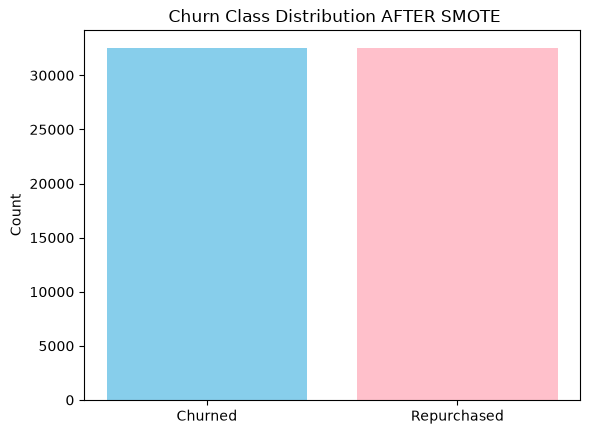

In [260]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(sampling_strategy="minority", random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

plt.bar(y_train_sm.value_counts().index, y_train_sm.value_counts().values, 
        color=["skyblue","pink"])
plt.xticks([0,1], ["Churned", "Repurchased"])
plt.ylabel("Count")
plt.title(" Churn Class Distribution AFTER SMOTE")
plt.show()

In [261]:
clf = DecisionTreeClassifier(criterion = "gini", max_depth = 5000, random_state= 42)


clf.fit(X_train_sm, y_train_sm)

,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",5000
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples 

In [262]:
ds_list = [
    ("Train", X_train_sm, y_train_sm),
    ("Val", X_val, y_val),
    ("Test", X_test, y_test)
]

for ds_name, ds_x, ds_y in ds_list:
    ds_y_pred = clf.predict(ds_x)

    print(ds_name)
    print('Model F1 score with gini index: {0:0.4f}'. format(f1_score(ds_y, ds_y_pred)))
    print('Model accuracy score with gini index: {0:0.4f}'. format(accuracy_score(ds_y, ds_y_pred)))

    cm = confusion_matrix(ds_y, ds_y_pred)
    print(cm)
    print()


Train
Model F1 score with gini index: 0.8275
Model accuracy score with gini index: 0.8097
[[22987  9545]
 [ 2837 29695]]

Val
Model F1 score with gini index: 0.0373
Model accuracy score with gini index: 0.7046
[[11481  4791]
 [   61    94]]

Test
Model F1 score with gini index: 0.0418
Model accuracy score with gini index: 0.7068
[[11506  4754]
 [   63   105]]



-----

# Random Forest

In [263]:
from sklearn.ensemble import RandomForestClassifier


rfcl = RandomForestClassifier(criterion= "gini", n_estimators=300, 
                               random_state=42, 
                               max_features = 'sqrt',
                               n_jobs=-1, verbose = 1)

# Fit on training data
rfcl.fit(X_train, y_train)

[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 8 concurrent workers.
[Parallel(n_jobs=-1)]: Done  34 tasks      | elapsed:    0.5s
[Parallel(n_jobs=-1)]: Done 184 tasks      | elapsed:    2.7s
[Parallel(n_jobs=-1)]: Done 300 out of 300 | elapsed:    4.7s finished


,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",300
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel. :meth:`fit`, :meth:`predict`,:meth:`decision_path` and :meth:`apply` are all parallelized over thetrees. ``None`` means 1 unless in a :obj:`joblib.parallel_backend`context. ``-1`` means using all processors. See :term:`Glossary<n_jobs>` for more details.",-1
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"verbose verbose: int, default=0Controls the verbosity when fitting and predicting.",1
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None


In [264]:
train_rf_predictions = rfcl.predict(X_train)
train_rf_probs = rfcl.predict_proba(X_train)

rf_predictions = rfcl.predict(X_test)
rf_probs = rfcl.predict_proba(X_test)

[Parallel(n_jobs=8)]: Using backend ThreadingBackend with 8 concurrent workers.
[Parallel(n_jobs=8)]: Done  34 tasks      | elapsed:    0.3s
[Parallel(n_jobs=8)]: Done 184 tasks      | elapsed:    0.7s
[Parallel(n_jobs=8)]: Done 300 out of 300 | elapsed:    1.0s finished
[Parallel(n_jobs=8)]: Using backend ThreadingBackend with 8 concurrent workers.
[Parallel(n_jobs=8)]: Done  34 tasks      | elapsed:    0.0s
[Parallel(n_jobs=8)]: Done 184 tasks      | elapsed:    0.5s
[Parallel(n_jobs=8)]: Done 300 out of 300 | elapsed:    0.8s finished
[Parallel(n_jobs=8)]: Using backend ThreadingBackend with 8 concurrent workers.
[Parallel(n_jobs=8)]: Done  34 tasks      | elapsed:    0.0s
[Parallel(n_jobs=8)]: Done 184 tasks      | elapsed:    0.2s
[Parallel(n_jobs=8)]: Done 300 out of 300 | elapsed:    0.5s finished
[Parallel(n_jobs=8)]: Using backend ThreadingBackend with 8 concurrent workers.
[Parallel(n_jobs=8)]: Done  34 tasks      | elapsed:    0.0s
[Parallel(n_jobs=8)]: Done 184 tasks      |

In [265]:
train_rf_probs

array([[0.98956087, 0.01043913],
       [1.        , 0.        ],
       [0.99883761, 0.00116239],
       ...,
       [0.99453843, 0.00546157],
       [1.        , 0.        ],
       [1.        , 0.        ]], shape=(32855, 2))

In [266]:
y_pred = rfcl.predict(X_test)

[Parallel(n_jobs=8)]: Using backend ThreadingBackend with 8 concurrent workers.
[Parallel(n_jobs=8)]: Done  34 tasks      | elapsed:    0.0s
[Parallel(n_jobs=8)]: Done 184 tasks      | elapsed:    0.4s
[Parallel(n_jobs=8)]: Done 300 out of 300 | elapsed:    0.6s finished


In [267]:
from sklearn.metrics import accuracy_score

print('Model accuracy score with 10 decision-trees : {0:0.4f}'. format(accuracy_score(y_test, y_pred)))

Model accuracy score with 10 decision-trees : 0.9905


In [268]:
cm = confusion_matrix(y_test, y_pred)


In [269]:
ds_list = [
    ("Train", X_train_sm, y_train_sm),
    ("Val", X_val, y_val),
    ("Test", X_test, y_test)
]

for ds_name, ds_x, ds_y in ds_list:
    ds_y_pred = rfcl.predict(ds_x)

    print(ds_name)
    print('Model F1 score with gini index: {0:0.4f}'. format(f1_score(ds_y, ds_y_pred)))
    print('Model accuracy score with gini index: {0:0.4f}'. format(accuracy_score(ds_y, ds_y_pred)))

    cm = confusion_matrix(ds_y, ds_y_pred)
    print(cm)
    print()

[Parallel(n_jobs=8)]: Using backend ThreadingBackend with 8 concurrent workers.
[Parallel(n_jobs=8)]: Done  34 tasks      | elapsed:    0.1s
[Parallel(n_jobs=8)]: Done 184 tasks      | elapsed:    0.9s
[Parallel(n_jobs=8)]: Done 300 out of 300 | elapsed:    1.4s finished
[Parallel(n_jobs=8)]: Using backend ThreadingBackend with 8 concurrent workers.


Train
Model F1 score with gini index: 0.0104
Model accuracy score with gini index: 0.5026
[[32532     0]
 [32362   170]]



[Parallel(n_jobs=8)]: Done  34 tasks      | elapsed:    0.0s
[Parallel(n_jobs=8)]: Done 184 tasks      | elapsed:    0.3s
[Parallel(n_jobs=8)]: Done 300 out of 300 | elapsed:    0.5s finished


Val
Model F1 score with gini index: 0.0864
Model accuracy score with gini index: 0.9910
[[16272     0]
 [  148     7]]



[Parallel(n_jobs=8)]: Using backend ThreadingBackend with 8 concurrent workers.
[Parallel(n_jobs=8)]: Done  34 tasks      | elapsed:    0.0s
[Parallel(n_jobs=8)]: Done 184 tasks      | elapsed:    0.3s
[Parallel(n_jobs=8)]: Done 300 out of 300 | elapsed:    0.5s finished


Test
Model F1 score with gini index: 0.1333
Model accuracy score with gini index: 0.9905
[[16260     0]
 [  156    12]]



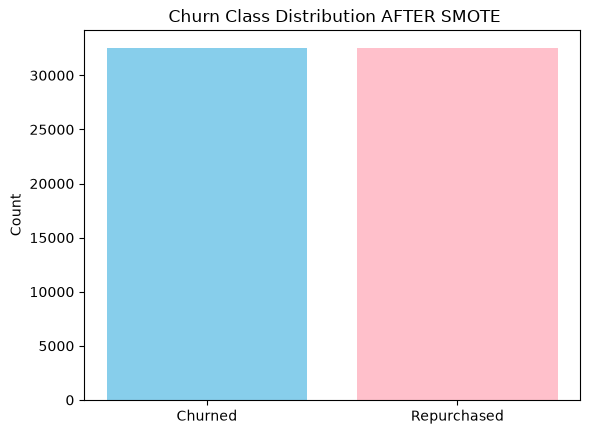

In [270]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(sampling_strategy="minority", random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

plt.bar(y_train_sm.value_counts().index, y_train_sm.value_counts().values, 
        color=["skyblue","pink"])
plt.xticks([0,1], ["Churned", "Repurchased"])
plt.ylabel("Count")
plt.title(" Churn Class Distribution AFTER SMOTE")
plt.show()

after oversampling

In [271]:
rfcl = RandomForestClassifier(criterion= "gini", n_estimators=300, 
                               random_state=42, 
                               max_features = 'sqrt',
                               n_jobs=-1, verbose = 1)

# Fit on training data
rfcl.fit(X_train_sm, y_train_sm)

[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 8 concurrent workers.
[Parallel(n_jobs=-1)]: Done  34 tasks      | elapsed:    1.4s
[Parallel(n_jobs=-1)]: Done 184 tasks      | elapsed:    7.2s
[Parallel(n_jobs=-1)]: Done 300 out of 300 | elapsed:   11.2s finished


,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",300
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel. :meth:`fit`, :meth:`predict`,:meth:`decision_path` and :meth:`apply` are all parallelized over thetrees. ``None`` means 1 unless in a :obj:`joblib.parallel_backend`context. ``-1`` means using all processors. See :term:`Glossary<n_jobs>` for more details.",-1
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"verbose verbose: int, default=0Controls the verbosity when fitting and predicting.",1
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None


In [272]:
ds_list = [
    ("Train", X_train_sm, y_train_sm),
    ("Val", X_val, y_val),
    ("Test", X_test, y_test)
]

for ds_name, ds_x, ds_y in ds_list:
    ds_y_pred = rfcl.predict(ds_x)

    print(ds_name)
    print('Model F1 score with gini index: {0:0.4f}'. format(f1_score(ds_y, ds_y_pred)))
    print('Model accuracy score with gini index: {0:0.4f}'. format(accuracy_score(ds_y, ds_y_pred)))

    cm = confusion_matrix(ds_y, ds_y_pred)
    print(cm)
    print()

[Parallel(n_jobs=8)]: Using backend ThreadingBackend with 8 concurrent workers.
[Parallel(n_jobs=8)]: Done  34 tasks      | elapsed:    0.0s
[Parallel(n_jobs=8)]: Done 184 tasks      | elapsed:    0.7s
[Parallel(n_jobs=8)]: Done 300 out of 300 | elapsed:    1.2s finished
[Parallel(n_jobs=8)]: Using backend ThreadingBackend with 8 concurrent workers.
[Parallel(n_jobs=8)]: Done  34 tasks      | elapsed:    0.0s


Train
Model F1 score with gini index: 0.8275
Model accuracy score with gini index: 0.8097
[[22985  9547]
 [ 2835 29697]]



[Parallel(n_jobs=8)]: Done 184 tasks      | elapsed:    0.2s
[Parallel(n_jobs=8)]: Done 300 out of 300 | elapsed:    0.3s finished


Val
Model F1 score with gini index: 0.0381
Model accuracy score with gini index: 0.7048
[[11481  4791]
 [   59    96]]



[Parallel(n_jobs=8)]: Using backend ThreadingBackend with 8 concurrent workers.
[Parallel(n_jobs=8)]: Done  34 tasks      | elapsed:    0.0s


Test
Model F1 score with gini index: 0.0418
Model accuracy score with gini index: 0.7067
[[11504  4756]
 [   63   105]]



[Parallel(n_jobs=8)]: Done 184 tasks      | elapsed:    0.2s
[Parallel(n_jobs=8)]: Done 300 out of 300 | elapsed:    0.4s finished


---

In [273]:
X_train.dtypes.value_counts()

int64    35
Name: count, dtype: int64

# XG Boost

In [ ]:
from xgboost import XGBClassifier


# declare parameters
params = {
            'objective':'binary:logistic',
            'max_depth': 6,
            'alpha': 10,
            'learning_rate': 1.0,
            'n_estimators':100
        }
            
            
            
# instantiate the classifier 
xgb_clf = XGBClassifier(**params)



# fit the classifier to the training data
xgb_clf.fit(X_train, y_train)

clf = DecisionTreeClassifier(criterion = "gini", max_depth = 5000, random_state= 42)


clf.fit(X_train_sm, y_train_sm)

,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",None
,feature_types feature_types: typing.Optional[typing.Sequence[str]].. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


In [280]:
X_val.dtypes.value_counts()

object    35
Name: count, dtype: int64

In [284]:
ds_list = [
    ("Train", X_train, y_train),
    ("Val", X_val, y_val),
    ("Test", X_test, y_test)
]

for ds_name, ds_x, ds_y in ds_list:
    print(ds_name)
    ds_y_pred = xgb_clf.predict(ds_x)

    print(ds_name)
    print('Model F1 score with gini index: {0:0.4f}'. format(f1_score(ds_y, ds_y_pred)))
    print('Model accuracy score with gini index: {0:0.4f}'. format(accuracy_score(ds_y, ds_y_pred)))

    cm = confusion_matrix(ds_y, ds_y_pred)
    print(cm)
    print()

Train
Train
Model F1 score with gini index: 0.0000
Model accuracy score with gini index: 0.9902
[[32532     0]
 [  323     0]]

Val
Val
Model F1 score with gini index: 0.0000
Model accuracy score with gini index: 0.9906
[[16272     0]
 [  155     0]]

Test
Test
Model F1 score with gini index: 0.0000
Model accuracy score with gini index: 0.9898
[[16260     0]
 [  168     0]]



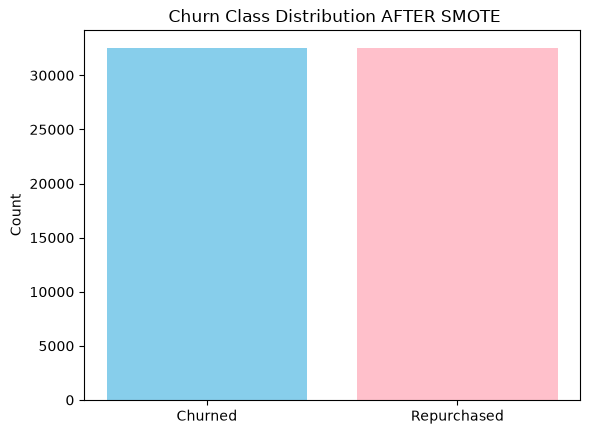

In [ ]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(sampling_strategy="minority", random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

plt.bar(y_train_sm.value_counts().index, y_train_sm.value_counts().values, 
        color=["skyblue","pink"])
plt.xticks([0,1], ["Churned", "Repurchased"])
plt.ylabel("Count")
plt.title(" Churn Class Distribution AFTER SMOTE")
plt.show()

after oversampling

In [ ]:

            
# instantiate the classifier 
xgb_clf = XGBClassifier(**params)



# fit the classifier to the training data
xgb_clf.fit(X_train_sm, y_train_sm)

,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",None
,feature_types feature_types: typing.Optional[typing.Sequence[str]].. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


In [ ]:
ds_list = [
    ("Trainsm", X_train_sm, y_train_sm),
    ("Train", X_train, y_train),
    ("Val", X_val, y_val),
    ("Test", X_test, y_test)
]

for ds_name, ds_x, ds_y in ds_list:
    ds_y_pred = xgb_clf.predict(ds_x)

    print(ds_name)
    print('Model F1 score with gini index: {0:0.4f}'. format(f1_score(ds_y, ds_y_pred)))
    print('Model accuracy score with gini index: {0:0.4f}'. format(accuracy_score(ds_y, ds_y_pred)))

    cm = confusion_matrix(ds_y, ds_y_pred)
    print(cm)
    print()

Trainsm
Model F1 score with gini index: 0.8240
Model accuracy score with gini index: 0.8070
[[23113  9419]
 [ 3140 29392]]

Train
Model F1 score with gini index: 0.0365
Model accuracy score with gini index: 0.7090
[[23113  9419]
 [  142   181]]

Val
Model F1 score with gini index: 0.0351
Model accuracy score with gini index: 0.7084
[[11550  4722]
 [   68    87]]

Test
Model F1 score with gini index: 0.0379
Model accuracy score with gini index: 0.7096
[[11563  4697]
 [   74    94]]



# Hyperparameter tunning


In [276]:
my_experiment_list = [
    {
        "name":"DT - gini",
        "clf":DecisionTreeClassifier,
        "params": {
            "criterion": "gini",
            "max_depth": 5000,
            "random_state": 42
        }
    },
    {
        "name":"DT - entropy",
        "clf":DecisionTreeClassifier,
        "params": {
            "criterion": "entropy",
            "max_depth": 5000,
            "random_state": 42
        }
    },
    {
        "name":"RF - gini_50",
        "clf":RandomForestClassifier,
        "params": {
            "criterion": "gini",
            "n_estimators": 50,
            "max_features": "sqrt",
            "random_state": 42,
            "n_jobs":-1
        }
    },
    {
        "name":"RF - gini_100",
        "clf":RandomForestClassifier,
        "params": {
            "criterion": "gini",
            "n_estimators": 100,
            "max_features": "sqrt",
            "random_state": 42,
            "n_jobs":-1
        }
    },
    {
        "name":"RF - gini_300",
        "clf":RandomForestClassifier,
        "params": {
            "criterion": "entropy",
            "n_estimators": 300,
            "max_features": "sqrt",
            "random_state": 42,
            "n_jobs":-1
        }
    },
    {
        "name":"LogReg",
        "clf":LogisticRegression,
        "params": {
            "random_state": 42
        }
    },
    {
        "name":"XGBoost - ",
        "clf":XGBClassifier,
        "params": {
            'objective':'binary:logistic',
            'max_depth': 20,
            'alpha': 10,
            'learning_rate': 1.0,
            'n_estimators':100
        }
    },
]

In [286]:
ds_list = [
    ("Trainsm", X_train_sm, y_train_sm),
    ("Train", X_train, y_train),
    ("Val", X_val, y_val),
    ("Test", X_test, y_test)
]

results = []

for exp in my_experiment_list:
    name = exp["name"]
    clf_class = exp["clf"]
    params = exp["params"]

    clf = clf_class(**params)
    clf.fit(X_train_sm, y_train_sm)

    exp_res = {
        "name": name
    }

    print("------------------------------------")
    print(name)
    print("------------------------------------")

    for ds_name, ds_x, ds_y in ds_list:
        ds_y_pred = clf.predict(ds_x)

        f1s = f1_score(ds_y, ds_y_pred)
        acc = accuracy_score(ds_y, ds_y_pred)
        print("----- ", ds_name, " -----")
        print('Model F1 score: {0:0.4f}'. format(f1s))
        print('Model accuracy: {0:0.4f}'. format(acc))

        cm = confusion_matrix(ds_y, ds_y_pred)
        tn, fp, fn, tp = cm.ravel()

        exp_res[ds_name + "_f1sore"] = f1s
        exp_res[ds_name + "_acc"] = acc

        exp_res[ds_name + "_tn"] = tn
        exp_res[ds_name + "_fp"] = fp
        exp_res[ds_name + "_fn"] = fn
        exp_res[ds_name + "_tp"] = tp

        print(cm)
        print()
    results.append(exp_res)
    print("------------------------------------")
    print()
    print()



------------------------------------
DT - gini
------------------------------------
-----  Trainsm  -----
Model F1 score: 0.8275
Model accuracy: 0.8097
[[22987  9545]
 [ 2837 29695]]

-----  Train  -----
Model F1 score: 0.0395
Model accuracy: 0.7057
[[22987  9545]
 [  124   199]]

-----  Val  -----
Model F1 score: 0.0373
Model accuracy: 0.7046
[[11481  4791]
 [   61    94]]

-----  Test  -----
Model F1 score: 0.0418
Model accuracy: 0.7068
[[11506  4754]
 [   63   105]]

------------------------------------


------------------------------------
DT - entropy
------------------------------------
-----  Trainsm  -----
Model F1 score: 0.8275
Model accuracy: 0.8097
[[22987  9545]
 [ 2837 29695]]

-----  Train  -----
Model F1 score: 0.0395
Model accuracy: 0.7057
[[22987  9545]
 [  124   199]]

-----  Val  -----
Model F1 score: 0.0373
Model accuracy: 0.7046
[[11481  4791]
 [   61    94]]

-----  Test  -----
Model F1 score: 0.0418
Model accuracy: 0.7068
[[11506  4754]
 [   63   105]]

--------

In [291]:
res_df = pd.DataFrame.from_records(results)
res_df = res_df.sort_values(by="Test_f1sore", ascending=False)
res_df

,name,Trainsm_f1sore,Trainsm_acc,Trainsm_tn,Trainsm_fp,Trainsm_fn,Trainsm_tp,Train_f1sore,Train_acc,Train_tn,...,Val_tn,Val_fp,Val_fn,Val_tp,Test_f1sore,Test_acc,Test_tn,Test_fp,Test_fn,Test_tp
2,RF - gini_50,0.827506,0.809695,22982,9550,2832,29700,0.040488,0.705707,22982,...,11479,4793,58,97,0.042528,0.706720,11503,4757,61,107
0,DT - gini,0.827481,0.809695,22987,9545,2837,29695,0.039535,0.705707,22987,...,11481,4791,61,94,0.041774,0.706781,11506,4754,63,105
1,DT - entropy,0.827481,0.809695,22987,9545,2837,29695,0.039535,0.705707,22987,...,11481,4791,61,94,0.041774,0.706781,11506,4754,63,105
3,RF - gini_100,0.827486,0.809695,22986,9546,2836,29696,0.039726,0.705707,22986,...,11481,4791,60,95,0.041766,0.706720,11505,4755,63,105
4,RF - gini_300,0.827491,0.809695,22985,9547,2835,29697,0.039917,0.705707,22985,...,11481,4791,59,96,0.041758,0.706659,11504,4756,63,105
6,XGBoost -,0.824248,0.807636,23199,9333,3183,29349,0.036800,0.711612,23199,...,11604,4668,68,87,0.038157,0.711529,11595,4665,74,94
5,LogReg,0.691232,0.713574,25568,6964,11672,20860,0.024936,0.781007,25568,...,12822,3450,106,49,0.023087,0.778488,12746,3514,125,43


--------
--------

## 120 days train_test dataset

In [ ]:
Data_train_120_df["state_income_level"] = Data_train_120_df.customer_state.map(prov_income_map)

Data_train_120_df["state_income_level_high"] = (Data_train_120_df["state_income_level"] == "high").astype(int)
Data_train_120_df["state_income_level_mid"] = (Data_train_120_df["state_income_level"] == "mid").astype(int)
Data_train_120_df["state_income_level_low"] = (Data_train_120_df["state_income_level"] == "low").astype(int)

Data_train_120_df

,customer_unique_id,price,freight_ratio,payment_value,dates_diff,review_score,customer_city,customer_state,order_status,payment_sequential,payment_type,payment_installments,product_cat,churn_120,state_income_level,state_income_level_high,state_income_level_mid,state_income_level_low
0,0000f46a3911fa3c0805444483337064,69.00,0.249565,86.22,-2.0,3.0,sao jose,SC,delivered,1.0,credit_card,8.0,office,0,low,0,0,1
1,0005e1862207bf6ccc02e4228effd9a0,135.00,0.112000,150.12,-28.0,4.0,teresopolis,RJ,delivered,1.0,credit_card,3.0,fashion,0,high,1,0,0
2,00115fc7123b5310cf6d3a3aa932699e,59.99,0.268711,76.11,-33.0,4.0,brasilia,DF,delivered,1.0,credit_card,1.0,sports_leisure,0,low,0,0,1
3,001f3c4211216384d5fe59b041ce1461,24.88,0.440514,35.84,-11.0,3.0,sao paulo,SP,delivered,1.0,credit_card,3.0,household,0,high,1,0,0
4,002043098f10ba39a4600b6c52fbfe3c,176.99,0.343635,237.81,-16.0,4.0,aracaju,SE,delivered,1.0,credit_card,4.0,office,0,high,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
23693,ffeefd086fc667aaf6595c8fe3d22d54,55.00,0.144364,62.94,-8.0,4.0,japeri,RJ,delivered,1.0,credit_card,3.0,beauty,0,high,1,0,0
23694,fff1afc79f6b5db1e235a4a6c30ceda7,34.99,0.431552,50.09,-16.0,5.0,erechim,RS,delivered,1.0,credit_card,4.0,beauty,0,low,0,0,1
23695,fff3a9369e4b7102fab406a334a678c3,84.90,0.210130,102.74,-7.0,5.0,brasilia,DF,delivered,1.0,credit_card,2.0,fashion,0,low,0,0,1
23696,fff699c184bcc967d62fa2c6171765f7,39.90,0.378446,55.00,-7.0,4.0,santos,SP,delivered,1.0,boleto,1.0,entertainment,0,high,1,0,0


In [ ]:

Data_train_120_df["high_review_score"] = (Data_train_120_df["review_score"]>= 4).astype(int)
Data_train_120_df["medium_review_score"] = ((Data_train_120_df["review_score"]< 4) & (Data_train_120_df["review_score"]>= 2)).astype(int)
Data_train_120_df["low_review_score"] = (Data_train_120_df["review_score"]< 2).astype(int)

Data_train_120_df


,customer_unique_id,price,freight_ratio,payment_value,dates_diff,review_score,customer_city,customer_state,order_status,payment_sequential,...,payment_installments,product_cat,churn_120,state_income_level,state_income_level_high,state_income_level_mid,state_income_level_low,high_review_score,medium_review_score,low_review_score
0,0000f46a3911fa3c0805444483337064,69.00,0.249565,86.22,-2.0,3.0,sao jose,SC,delivered,1.0,...,8.0,office,0,low,0,0,1,0,1,0
1,0005e1862207bf6ccc02e4228effd9a0,135.00,0.112000,150.12,-28.0,4.0,teresopolis,RJ,delivered,1.0,...,3.0,fashion,0,high,1,0,0,1,0,0
2,00115fc7123b5310cf6d3a3aa932699e,59.99,0.268711,76.11,-33.0,4.0,brasilia,DF,delivered,1.0,...,1.0,sports_leisure,0,low,0,0,1,1,0,0
3,001f3c4211216384d5fe59b041ce1461,24.88,0.440514,35.84,-11.0,3.0,sao paulo,SP,delivered,1.0,...,3.0,household,0,high,1,0,0,0,1,0
4,002043098f10ba39a4600b6c52fbfe3c,176.99,0.343635,237.81,-16.0,4.0,aracaju,SE,delivered,1.0,...,4.0,office,0,high,1,0,0,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
23693,ffeefd086fc667aaf6595c8fe3d22d54,55.00,0.144364,62.94,-8.0,4.0,japeri,RJ,delivered,1.0,...,3.0,beauty,0,high,1,0,0,1,0,0
23694,fff1afc79f6b5db1e235a4a6c30ceda7,34.99,0.431552,50.09,-16.0,5.0,erechim,RS,delivered,1.0,...,4.0,beauty,0,low,0,0,1,1,0,0
23695,fff3a9369e4b7102fab406a334a678c3,84.90,0.210130,102.74,-7.0,5.0,brasilia,DF,delivered,1.0,...,2.0,fashion,0,low,0,0,1,1,0,0
23696,fff699c184bcc967d62fa2c6171765f7,39.90,0.378446,55.00,-7.0,4.0,santos,SP,delivered,1.0,...,1.0,entertainment,0,high,1,0,0,1,0,0


In [ ]:
Data_train_120_df["delay"] = (Data_train_120_df["dates_diff"]>0).astype(int)

Data_train_120_df["delay"]

0        0
1        0
2        0
3        0
4        0
        ..
23693    0
23694    0
23695    0
23696    0
23697    0
Name: delay, Length: 23698, dtype: int64

In [ ]:
Data_train_120_df["high_payment_value"] = (Data_train_120_df["payment_value"]>172.73).astype(int)

Data_train_120_df["high_payment_value"]

0        0
1        0
2        0
3        0
4        1
        ..
23693    0
23694    0
23695    0
23696    0
23697    0
Name: high_payment_value, Length: 23698, dtype: int64

In [ ]:
Data_train_120_df["expensive_freight"] = (Data_train_120_df["freight_ratio"]>0.15).astype(int)

Data_train_120_df["expensive_freight"]

0        1
1        0
2        1
3        1
4        1
        ..
23693    0
23694    1
23695    1
23696    1
23697    1
Name: expensive_freight, Length: 23698, dtype: int64

In [ ]:
Data_train_120_df["is_high_price"] = (Data_train_120_df["price"]>120.64).astype(int)

Data_train_120_df["is_high_price"]

0        0
1        1
2        0
3        0
4        1
        ..
23693    0
23694    0
23695    0
23696    0
23697    0
Name: is_high_price, Length: 23698, dtype: int64

In [ ]:
Data_train_120_df["beyond_one year"] = (Data_train_120_df["payment_installments"] > 12.0).astype(int)

Data_train_120_df["beyond_one year"]

0        0
1        0
2        0
3        0
4        0
        ..
23693    0
23694    0
23695    0
23696    0
23697    0
Name: beyond_one year, Length: 23698, dtype: int64

In [ ]:
Data_train_120_df["multiple_payment_methods"] = (Data_train_120_df["payment_sequential"] > 2.0).astype(int)

Data_train_120_df["multiple_payment_methods"]

0        0
1        0
2        0
3        0
4        0
        ..
23693    0
23694    0
23695    0
23696    0
23697    0
Name: multiple_payment_methods, Length: 23698, dtype: int64

In [ ]:
target_features = ["order_status", "payment_type", "product_cat"]

col_trans = ColumnTransformer(
    transformers=[("cat", OneHotEncoder(sparse_output= False, drop="first", handle_unknown="ignore"), target_features)], remainder="passthrough"
)
col_trans.fit(Data_train_120_df)

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'passthrough'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_name``. e.g. 

In [ ]:
encoded_array = col_trans.transform(Data_train_120_df)

In [ ]:
encoded_120_df = pd.DataFrame(encoded_array, columns= col_trans.get_feature_names_out(Data_train_120_df.columns))

encoded_120_df

,cat__order_status_canceled,cat__order_status_delivered,cat__order_status_invoiced,cat__order_status_processing,cat__order_status_shipped,cat__payment_type_credit_card,cat__payment_type_debit_card,cat__payment_type_voucher,cat__product_cat_babies,cat__product_cat_beauty,...,remainder__state_income_level_low,remainder__high_review_score,remainder__medium_review_score,remainder__low_review_score,remainder__delay,remainder__high_payment_value,remainder__expensive_freight,remainder__is_high_price,remainder__beyond_one year,remainder__multiple_payment_methods
0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,1,0,1,0,0,0,1,0,0,0
1,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,0,1,0,0,0,0,0,1,0,0
2,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,1,1,0,0,0,0,1,0,0,0
3,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,0,0,1,0,0,0,1,0,0,0
4,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,0,1,0,0,0,1,1,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
23693,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,...,0,1,0,0,0,0,0,0,0,0
23694,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,...,1,1,0,0,0,0,1,0,0,0
23695,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,1,1,0,0,0,0,1,0,0,0
23696,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0,1,0,0,0,0,1,0,0,0


In [ ]:
encoded_120_df.columns = encoded_120_df.columns.str.replace('remainder__', '')

encoded_120_df

,cat__order_status_canceled,cat__order_status_delivered,cat__order_status_invoiced,cat__order_status_processing,cat__order_status_shipped,cat__payment_type_credit_card,cat__payment_type_debit_card,cat__payment_type_voucher,cat__product_cat_babies,cat__product_cat_beauty,...,state_income_level_low,high_review_score,medium_review_score,low_review_score,delay,high_payment_value,expensive_freight,is_high_price,beyond_one year,multiple_payment_methods
0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,1,0,1,0,0,0,1,0,0,0
1,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,0,1,0,0,0,0,0,1,0,0
2,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,1,1,0,0,0,0,1,0,0,0
3,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,0,0,1,0,0,0,1,0,0,0
4,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,0,1,0,0,0,1,1,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
23693,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,...,0,1,0,0,0,0,0,0,0,0
23694,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,...,1,1,0,0,0,0,1,0,0,0
23695,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,1,1,0,0,0,0,1,0,0,0
23696,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0,1,0,0,0,0,1,0,0,0


-----

## Test dataset

In [ ]:
Data_test_120_df

,customer_unique_id,price,freight_ratio,payment_value,dates_diff,review_score,customer_city,customer_state,order_status,payment_sequential,payment_type,payment_installments,product_cat,churn_120
0,0000366f3b9a7992bf8c76cfdf3221e2,129.90,0.092379,141.90,-5.0,5.0,cajamar,SP,delivered,1.0,credit_card,8.0,household,0
1,0000b849f77a49e4a4ce2b2a4ca5be3f,18.90,0.438624,27.19,-5.0,4.0,osasco,SP,delivered,1.0,credit_card,1.0,beauty,0
2,0004bd2a26a76fe21f786e4fbd80607f,154.00,0.084286,166.98,-12.0,4.0,sao paulo,SP,delivered,1.0,credit_card,8.0,miscellaneous,0
3,00050ab1314c0e55a6ca13cf7181fecf,27.99,0.264023,35.38,-12.0,4.0,campinas,SP,delivered,1.0,boleto,1.0,electronics,0
4,00053a61a98854899e70ed204dd4bafe,382.00,0.097330,838.36,-10.0,1.0,curitiba,PR,delivered,1.0,credit_card,3.0,sports_leisure,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
28212,ffeddf8aa7cdecf403e77b2e9a99e2ea,330.00,0.237576,204.20,6.0,2.0,santarem,PA,delivered,2.0,credit_card,5.0,office,0
28213,fff1bdd5c5e37ca79dd74deeb91aa5b6,134.90,0.282283,172.98,32.0,1.0,araguaina,TO,delivered,2.0,debit_card,1.0,entertainment,0
28214,fff2ae16b99c6f3c785f0e052f2a9cfb,129.94,0.546098,200.90,-21.0,5.0,rio de janeiro,RJ,delivered,1.0,credit_card,8.0,office,0
28215,fffcc512b7dfecaffd80f13614af1d16,688.00,0.032994,710.70,0.0,1.0,cabo frio,RJ,shipped,1.0,credit_card,3.0,beauty,0


In [ ]:
Data_test_120_df["state_income_level"] = Data_test_120_df.customer_state.map(prov_income_map)

Data_test_120_df["state_income_level_high"] = (Data_test_120_df["state_income_level"] == "high").astype(int)
Data_test_120_df["state_income_level_mid"] = (Data_test_120_df["state_income_level"] == "mid").astype(int)
Data_test_120_df["state_income_level_low"] = (Data_test_120_df["state_income_level"] == "low").astype(int)

Data_test_120_df 

,customer_unique_id,price,freight_ratio,payment_value,dates_diff,review_score,customer_city,customer_state,order_status,payment_sequential,payment_type,payment_installments,product_cat,churn_120,state_income_level,state_income_level_high,state_income_level_mid,state_income_level_low
0,0000366f3b9a7992bf8c76cfdf3221e2,129.90,0.092379,141.90,-5.0,5.0,cajamar,SP,delivered,1.0,credit_card,8.0,household,0,high,1,0,0
1,0000b849f77a49e4a4ce2b2a4ca5be3f,18.90,0.438624,27.19,-5.0,4.0,osasco,SP,delivered,1.0,credit_card,1.0,beauty,0,high,1,0,0
2,0004bd2a26a76fe21f786e4fbd80607f,154.00,0.084286,166.98,-12.0,4.0,sao paulo,SP,delivered,1.0,credit_card,8.0,miscellaneous,0,high,1,0,0
3,00050ab1314c0e55a6ca13cf7181fecf,27.99,0.264023,35.38,-12.0,4.0,campinas,SP,delivered,1.0,boleto,1.0,electronics,0,high,1,0,0
4,00053a61a98854899e70ed204dd4bafe,382.00,0.097330,838.36,-10.0,1.0,curitiba,PR,delivered,1.0,credit_card,3.0,sports_leisure,0,low,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
28212,ffeddf8aa7cdecf403e77b2e9a99e2ea,330.00,0.237576,204.20,6.0,2.0,santarem,PA,delivered,2.0,credit_card,5.0,office,0,low,0,0,1
28213,fff1bdd5c5e37ca79dd74deeb91aa5b6,134.90,0.282283,172.98,32.0,1.0,araguaina,TO,delivered,2.0,debit_card,1.0,entertainment,0,low,0,0,1
28214,fff2ae16b99c6f3c785f0e052f2a9cfb,129.94,0.546098,200.90,-21.0,5.0,rio de janeiro,RJ,delivered,1.0,credit_card,8.0,office,0,high,1,0,0
28215,fffcc512b7dfecaffd80f13614af1d16,688.00,0.032994,710.70,0.0,1.0,cabo frio,RJ,shipped,1.0,credit_card,3.0,beauty,0,high,1,0,0


In [ ]:
Data_test_120_df["high_review_score"] = (Data_test_120_df["review_score"]>= 4).astype(int)
Data_test_120_df["medium_review_score"] = ((Data_test_120_df["review_score"]< 4) & (Data_test_120_df["review_score"]>= 2)).astype(int)
Data_test_120_df["low_review_score"] = (Data_test_120_df["review_score"]< 2).astype(int)

Data_test_120_df

,customer_unique_id,price,freight_ratio,payment_value,dates_diff,review_score,customer_city,customer_state,order_status,payment_sequential,...,payment_installments,product_cat,churn_120,state_income_level,state_income_level_high,state_income_level_mid,state_income_level_low,high_review_score,medium_review_score,low_review_score
0,0000366f3b9a7992bf8c76cfdf3221e2,129.90,0.092379,141.90,-5.0,5.0,cajamar,SP,delivered,1.0,...,8.0,household,0,high,1,0,0,1,0,0
1,0000b849f77a49e4a4ce2b2a4ca5be3f,18.90,0.438624,27.19,-5.0,4.0,osasco,SP,delivered,1.0,...,1.0,beauty,0,high,1,0,0,1,0,0
2,0004bd2a26a76fe21f786e4fbd80607f,154.00,0.084286,166.98,-12.0,4.0,sao paulo,SP,delivered,1.0,...,8.0,miscellaneous,0,high,1,0,0,1,0,0
3,00050ab1314c0e55a6ca13cf7181fecf,27.99,0.264023,35.38,-12.0,4.0,campinas,SP,delivered,1.0,...,1.0,electronics,0,high,1,0,0,1,0,0
4,00053a61a98854899e70ed204dd4bafe,382.00,0.097330,838.36,-10.0,1.0,curitiba,PR,delivered,1.0,...,3.0,sports_leisure,0,low,0,0,1,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
28212,ffeddf8aa7cdecf403e77b2e9a99e2ea,330.00,0.237576,204.20,6.0,2.0,santarem,PA,delivered,2.0,...,5.0,office,0,low,0,0,1,0,1,0
28213,fff1bdd5c5e37ca79dd74deeb91aa5b6,134.90,0.282283,172.98,32.0,1.0,araguaina,TO,delivered,2.0,...,1.0,entertainment,0,low,0,0,1,0,0,1
28214,fff2ae16b99c6f3c785f0e052f2a9cfb,129.94,0.546098,200.90,-21.0,5.0,rio de janeiro,RJ,delivered,1.0,...,8.0,office,0,high,1,0,0,1,0,0
28215,fffcc512b7dfecaffd80f13614af1d16,688.00,0.032994,710.70,0.0,1.0,cabo frio,RJ,shipped,1.0,...,3.0,beauty,0,high,1,0,0,0,0,1


In [ ]:
Data_test_120_df["delay"] = (Data_test_120_df["dates_diff"]>0).astype(int)

Data_test_120_df["delay"]

0        0
1        0
2        0
3        0
4        0
        ..
28212    1
28213    1
28214    0
28215    0
28216    0
Name: delay, Length: 28217, dtype: int64

In [ ]:
Data_test_120_df["high_payment_value"] = (Data_test_120_df["payment_value"]>172.73).astype(int)

Data_test_120_df["high_payment_value"]

0        0
1        0
2        0
3        0
4        1
        ..
28212    1
28213    1
28214    1
28215    1
28216    0
Name: high_payment_value, Length: 28217, dtype: int64

In [ ]:
Data_test_120_df["expensive_freight"] = (Data_test_120_df["freight_ratio"]>0.15).astype(int)

Data_test_120_df["expensive_freight"]

0        0
1        1
2        0
3        1
4        0
        ..
28212    1
28213    1
28214    1
28215    0
28216    1
Name: expensive_freight, Length: 28217, dtype: int64

In [ ]:
Data_test_120_df["is_high_price"] = (Data_test_120_df["price"]>120.64).astype(int)

Data_test_120_df["is_high_price"] 

0        1
1        0
2        1
3        0
4        1
        ..
28212    1
28213    1
28214    1
28215    1
28216    0
Name: is_high_price, Length: 28217, dtype: int64

In [ ]:
Data_test_120_df["beyond_one year"] = (Data_test_120_df["payment_installments"] > 12.0).astype(int)

Data_test_120_df["beyond_one year"]

0        0
1        0
2        0
3        0
4        0
        ..
28212    0
28213    0
28214    0
28215    0
28216    0
Name: beyond_one year, Length: 28217, dtype: int64

In [ ]:
Data_test_120_df["multiple_payment_methods"] = (Data_test_120_df["payment_sequential"] > 2.0).astype(int)

Data_test_120_df["multiple_payment_methods"]

0        0
1        0
2        0
3        0
4        0
        ..
28212    0
28213    0
28214    0
28215    0
28216    0
Name: multiple_payment_methods, Length: 28217, dtype: int64

In [ ]:
encoded_array_test = col_trans.transform(Data_test_120_df)

In [ ]:
encoded_120_test_df = pd.DataFrame(encoded_array_test, columns= col_trans.get_feature_names_out(Data_test_120_df.columns))

encoded_120_test_df

,cat__order_status_canceled,cat__order_status_delivered,cat__order_status_invoiced,cat__order_status_processing,cat__order_status_shipped,cat__payment_type_credit_card,cat__payment_type_debit_card,cat__payment_type_voucher,cat__product_cat_babies,cat__product_cat_beauty,...,remainder__state_income_level_low,remainder__high_review_score,remainder__medium_review_score,remainder__low_review_score,remainder__delay,remainder__high_payment_value,remainder__expensive_freight,remainder__is_high_price,remainder__beyond_one year,remainder__multiple_payment_methods
0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,0,1,0,0,0,0,0,1,0,0
1,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,...,0,1,0,0,0,0,1,0,0,0
2,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,0,1,0,0,0,0,0,1,0,0
3,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0,1,0,0,0,0,1,0,0,0
4,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,1,0,0,1,0,1,0,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
28212,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,1,0,1,0,1,1,1,1,0,0
28213,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,1,0,0,1,1,1,1,1,0,0
28214,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,0,1,0,0,0,1,1,1,0,0
28215,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,...,0,0,0,1,0,1,0,1,0,0


In [ ]:
encoded_120_test_df.columns = encoded_120_test_df.columns.str.replace('remainder__', '')

encoded_120_test_df

,cat__order_status_canceled,cat__order_status_delivered,cat__order_status_invoiced,cat__order_status_processing,cat__order_status_shipped,cat__payment_type_credit_card,cat__payment_type_debit_card,cat__payment_type_voucher,cat__product_cat_babies,cat__product_cat_beauty,...,state_income_level_low,high_review_score,medium_review_score,low_review_score,delay,high_payment_value,expensive_freight,is_high_price,beyond_one year,multiple_payment_methods
0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,0,1,0,0,0,0,0,1,0,0
1,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,...,0,1,0,0,0,0,1,0,0,0
2,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,0,1,0,0,0,0,0,1,0,0
3,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0,1,0,0,0,0,1,0,0,0
4,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,1,0,0,1,0,1,0,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
28212,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,1,0,1,0,1,1,1,1,0,0
28213,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,1,0,0,1,1,1,1,1,0,0
28214,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,0,1,0,0,0,1,1,1,0,0
28215,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,...,0,0,0,1,0,1,0,1,0,0


-----

## Train test split

In [ ]:
X_train = encoded_120_test_df.drop(columns = ['churn_120', "customer_unique_id",  "customer_city", "customer_state", "payment_sequential", "payment_installments",	"state_income_level", "price", "freight_ratio", "payment_value", "dates_diff",	"review_score"])

y_train = encoded_120_test_df['churn_120'].fillna(0).astype(int)

In [ ]:
X_valtest = encoded_120_test_df.drop(columns = ['churn_120', "customer_unique_id", "customer_city", "customer_state", "payment_sequential", "payment_installments",	"state_income_level", "price", "freight_ratio", "payment_value", "dates_diff",	"review_score"])

y_valtest = encoded_120_test_df['churn_120'].fillna(0).astype(int)

In [ ]:
from sklearn.model_selection import train_test_split

X_val, X_test, y_val, y_test  =  train_test_split(X_valtest, y_valtest, test_size= 0.5, random_state = 42)

In [ ]:
print(X_train.shape)
print(X_valtest.shape)

(28217, 35)
(28217, 35)


In [ ]:
X_train = X_train.astype(int)

X_val = X_val.astype(int)

X_test = X_test.astype(int)

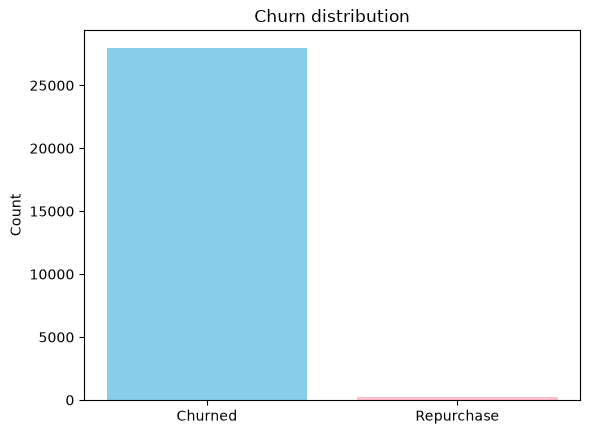

In [ ]:
plt.bar(y_train.value_counts().index, y_train.value_counts().values, color=['skyblue','pink'])
plt.xticks([0,1], ["Churned", "Repurchase"])
plt.ylabel("Count")
plt.title("Churn distribution")
plt.show()

In [ ]:
X_valtest.columns

Index(['cat__order_status_canceled', 'cat__order_status_delivered',
       'cat__order_status_invoiced', 'cat__order_status_processing',
       'cat__order_status_shipped', 'cat__payment_type_credit_card',
       'cat__payment_type_debit_card', 'cat__payment_type_voucher',
       'cat__product_cat_babies', 'cat__product_cat_beauty',
       'cat__product_cat_books_media',
       'cat__product_cat_commercial_industrial',
       'cat__product_cat_construction', 'cat__product_cat_electronics',
       'cat__product_cat_entertainment', 'cat__product_cat_fashion',
       'cat__product_cat_food_drink', 'cat__product_cat_household',
       'cat__product_cat_miscellaneous', 'cat__product_cat_office',
       'cat__product_cat_pet_shop', 'cat__product_cat_sports_leisure',
       'cat__product_cat_unknown', 'state_income_level_high',
       'state_income_level_mid', 'state_income_level_low', 'high_review_score',
       'medium_review_score', 'low_review_score', 'delay',
       'high_payment_value',

----

## Logistic Regression

In [ ]:

lr = LogisticRegression( random_state= 42)


# fit the model
lr.fit(X_train, y_train)

,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",42
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solve

In [ ]:
pd.DataFrame(list(zip(X_train.columns, lr.coef_[0])), columns= ["Feature_name", "Coefficient"])

,Feature_name,Coefficient
0,cat__order_status_canceled,-0.484025
1,cat__order_status_delivered,-0.770113
2,cat__order_status_invoiced,-0.434575
3,cat__order_status_processing,0.113717
4,cat__order_status_shipped,-0.476112
5,cat__payment_type_credit_card,0.094093
6,cat__payment_type_debit_card,-0.206299
7,cat__payment_type_voucher,-0.157795
8,cat__product_cat_babies,-0.504612
9,cat__product_cat_beauty,-0.188401


In [ ]:


model_stm = stm.Logit(y_train, X_train).fit()

print(model_stm.summary())

         Current function value: 0.048861
         Iterations: 35


c:\Users\Hallen\anaconda3\envs\silv_env\Lib\site-packages\statsmodels\discrete\discrete_model.py:268: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  mlefit = super().fit(


                           Logit Regression Results                           
Dep. Variable:              churn_120   No. Observations:                28217
Model:                          Logit   Df Residuals:                    28183
Method:                           MLE   Df Model:                           33
Date:                Sun, 13 Sep 2026   Pseudo R-squ.:                 0.01998
Time:                        13:37:55   Log-Likelihood:                -1378.7
converged:                      False   LL-Null:                       -1406.8
Covariance Type:            nonrobust   LLR p-value:                  0.007111
                                             coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------------------------
cat__order_status_canceled                 0.8692        nan        nan        nan         nan         nan
cat__order_status_delivered                0.78

In [ ]:
ds_list = [
    ("Train", X_train, y_train),
    ("Val", X_val, y_val),
    ("Test", X_test, y_test)
]

for ds_name, ds_x, ds_y in ds_list:
    ds_y_pred = lr.predict(ds_x)

    print(ds_name)
    print('Model F1 score with gini index: {0:0.4f}'. format(f1_score(ds_y, ds_y_pred)))
    print('Model accuracy score with gini index: {0:0.4f}'. format(accuracy_score(ds_y, ds_y_pred)))

    cm = confusion_matrix(ds_y, ds_y_pred)
    print(cm)
    print()


Train
Model F1 score with gini index: 0.0000
Model accuracy score with gini index: 0.9913
[[27972     0]
 [  245     0]]

Val
Model F1 score with gini index: 0.0000
Model accuracy score with gini index: 0.9909
[[13979     0]
 [  129     0]]

Test
Model F1 score with gini index: 0.0000
Model accuracy score with gini index: 0.9918
[[13993     0]
 [  116     0]]



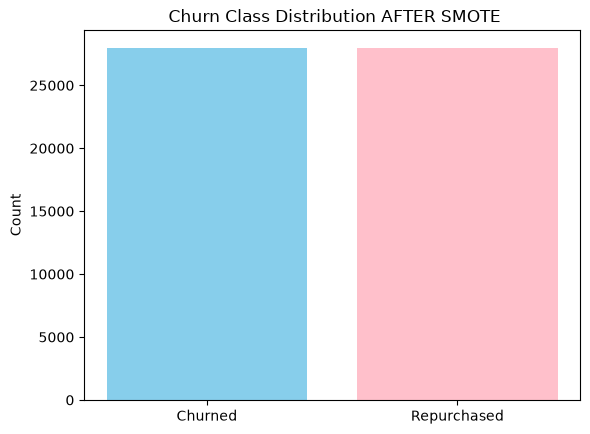

In [ ]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(sampling_strategy="minority", random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

plt.bar(y_train_sm.value_counts().index, y_train_sm.value_counts().values, 
        color=["skyblue","pink"])
plt.xticks([0,1], ["Churned", "Repurchased"])
plt.ylabel("Count")
plt.title(" Churn Class Distribution AFTER SMOTE")
plt.show()

In [ ]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression( random_state= 42)


# fit the model
lr.fit(X_train_sm, y_train_sm)

,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",42
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solve

In [ ]:
pd.DataFrame(list(zip(X_train.columns, lr.coef_[0])), columns= ["Feature_name", "Coefficient"])

,Feature_name,Coefficient
0,cat__order_status_canceled,-5.469618
1,cat__order_status_delivered,-3.457442
2,cat__order_status_invoiced,-4.925489
3,cat__order_status_processing,-3.744137
4,cat__order_status_shipped,-5.052301
5,cat__payment_type_credit_card,-0.090978
6,cat__payment_type_debit_card,-3.783690
7,cat__payment_type_voucher,-2.556551
8,cat__product_cat_babies,-4.927853
9,cat__product_cat_beauty,-2.704558


In [ ]:
import statsmodels.api as stm

model_stm = stm.Logit(y_train, X_train).fit()

print(model_stm.summary())

         Current function value: 0.048861
         Iterations: 35


c:\Users\Hallen\anaconda3\envs\silv_env\Lib\site-packages\statsmodels\discrete\discrete_model.py:268: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  mlefit = super().fit(


                           Logit Regression Results                           
Dep. Variable:              churn_120   No. Observations:                28217
Model:                          Logit   Df Residuals:                    28183
Method:                           MLE   Df Model:                           33
Date:                Sun, 13 Sep 2026   Pseudo R-squ.:                 0.01998
Time:                        13:37:59   Log-Likelihood:                -1378.7
converged:                      False   LL-Null:                       -1406.8
Covariance Type:            nonrobust   LLR p-value:                  0.007111
                                             coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------------------------
cat__order_status_canceled                 0.8692        nan        nan        nan         nan         nan
cat__order_status_delivered                0.78

In [ ]:
ds_list = [
    ("Train", X_train, y_train),
    ("Val", X_val, y_val),
    ("Test", X_test, y_test)
]

for ds_name, ds_x, ds_y in ds_list:
    ds_y_pred = lr.predict(ds_x)

    print(ds_name)
    print('Model F1 score with gini index: {0:0.4f}'. format(f1_score(ds_y, ds_y_pred)))
    print('Model accuracy score with gini index: {0:0.4f}'. format(accuracy_score(ds_y, ds_y_pred)))

    cm = confusion_matrix(ds_y, ds_y_pred)
    print(cm)
    print()

Train
Model F1 score with gini index: 0.0235
Model accuracy score with gini index: 0.7823
[[21999  5973]
 [  171    74]]

Val
Model F1 score with gini index: 0.0223
Model accuracy score with gini index: 0.7827
[[11007  2972]
 [   94    35]]

Test
Model F1 score with gini index: 0.0247
Model accuracy score with gini index: 0.7818
[[10992  3001]
 [   77    39]]



-----

# Gini criterion

## Decision Tree

In [ ]:
clf = DecisionTreeClassifier(criterion = "gini", max_depth = 5000, random_state= 42)


clf.fit(X_train, y_train)

,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",5000
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples 

In [ ]:
ds_list = [
    ("Train", X_train, y_train),
    ("Val", X_val, y_val),
    ("Test", X_test, y_test)
]

for ds_name, ds_x, ds_y in ds_list:
    ds_y_pred = clf.predict(ds_x)

    print(ds_name)
    print('Model F1 score with gini index: {0:0.4f}'. format(f1_score(ds_y, ds_y_pred)))
    print('Model accuracy score with gini index: {0:0.4f}'. format(accuracy_score(ds_y, ds_y_pred)))

    cm = confusion_matrix(ds_y, ds_y_pred)
    print(cm)
    print()

Train
Model F1 score with gini index: 0.1081
Model accuracy score with gini index: 0.9918
[[27972     0]
 [  231    14]]

Val
Model F1 score with gini index: 0.1029
Model accuracy score with gini index: 0.9914
[[13979     0]
 [  122     7]]

Test
Model F1 score with gini index: 0.1138
Model accuracy score with gini index: 0.9923
[[13993     0]
 [  109     7]]



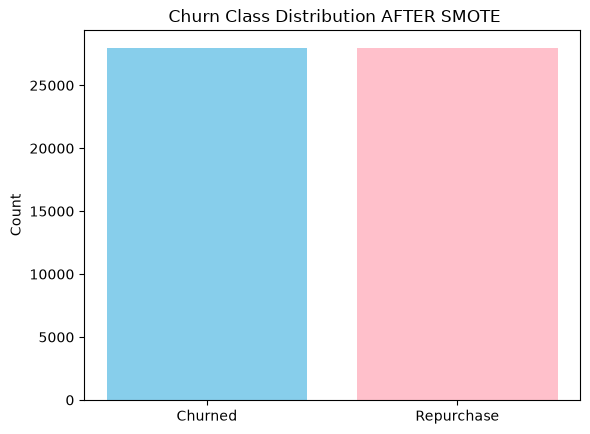

In [ ]:
smote = SMOTE(sampling_strategy="minority", random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

plt.bar(y_train_sm.value_counts().index, y_train_sm.value_counts().values, 
        color=["skyblue","pink"])
plt.xticks([0,1], ["Churned", "Repurchase"])
plt.ylabel("Count")
plt.title(" Churn Class Distribution AFTER SMOTE")
plt.show()

In [ ]:
clf = DecisionTreeClassifier(criterion = "gini", max_depth = 5000, random_state= 42)


clf.fit(X_train_sm, y_train_sm)

,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",5000
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples 

In [ ]:
ds_list = [
    ("Train", X_train_sm, y_train_sm),
    ("Val", X_val, y_val),
    ("Test", X_test, y_test)
]

for ds_name, ds_x, ds_y in ds_list:
    ds_y_pred = clf.predict(ds_x)

    print(ds_name)
    print('Model F1 score with gini index: {0:0.4f}'. format(f1_score(ds_y, ds_y_pred)))
    print('Model accuracy score with gini index: {0:0.4f}'. format(accuracy_score(ds_y, ds_y_pred)))

    cm = confusion_matrix(ds_y, ds_y_pred)
    print(cm)
    print()

Train
Model F1 score with gini index: 0.8475
Model accuracy score with gini index: 0.8307
[[20169  7803]
 [ 1666 26306]]

Val
Model F1 score with gini index: 0.0336
Model accuracy score with gini index: 0.7229
[[10131  3848]
 [   61    68]]

Test
Model F1 score with gini index: 0.0352
Model accuracy score with gini index: 0.7166
[[10038  3955]
 [   43    73]]



-----

# Random Forest

In [ ]:
from sklearn.ensemble import RandomForestClassifier


rfcl = RandomForestClassifier(criterion= "gini", n_estimators=300, 
                               random_state=42, 
                               max_features = 'sqrt',
                               n_jobs=-1, verbose = 1)

# Fit on training data
rfcl.fit(X_train, y_train)

[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 8 concurrent workers.
[Parallel(n_jobs=-1)]: Done  34 tasks      | elapsed:    0.5s
[Parallel(n_jobs=-1)]: Done 184 tasks      | elapsed:    2.7s
[Parallel(n_jobs=-1)]: Done 300 out of 300 | elapsed:    3.9s finished


,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",300
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel. :meth:`fit`, :meth:`predict`,:meth:`decision_path` and :meth:`apply` are all parallelized over thetrees. ``None`` means 1 unless in a :obj:`joblib.parallel_backend`context. ``-1`` means using all processors. See :term:`Glossary<n_jobs>` for more details.",-1
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"verbose verbose: int, default=0Controls the verbosity when fitting and predicting.",1
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None


In [ ]:
train_rf_predictions = rfcl.predict(X_train)
train_rf_probs = rfcl.predict_proba(X_train)

rf_predictions = rfcl.predict(X_test)
rf_probs = rfcl.predict_proba(X_test)

[Parallel(n_jobs=8)]: Using backend ThreadingBackend with 8 concurrent workers.
[Parallel(n_jobs=8)]: Done  34 tasks      | elapsed:    0.0s
[Parallel(n_jobs=8)]: Done 184 tasks      | elapsed:    0.3s
[Parallel(n_jobs=8)]: Done 300 out of 300 | elapsed:    0.6s finished
[Parallel(n_jobs=8)]: Using backend ThreadingBackend with 8 concurrent workers.
[Parallel(n_jobs=8)]: Done  34 tasks      | elapsed:    0.0s
[Parallel(n_jobs=8)]: Done 184 tasks      | elapsed:    0.3s
[Parallel(n_jobs=8)]: Done 300 out of 300 | elapsed:    0.6s finished
[Parallel(n_jobs=8)]: Using backend ThreadingBackend with 8 concurrent workers.
[Parallel(n_jobs=8)]: Done  34 tasks      | elapsed:    0.0s
[Parallel(n_jobs=8)]: Done 184 tasks      | elapsed:    0.2s
[Parallel(n_jobs=8)]: Done 300 out of 300 | elapsed:    0.3s finished
[Parallel(n_jobs=8)]: Using backend ThreadingBackend with 8 concurrent workers.
[Parallel(n_jobs=8)]: Done  34 tasks      | elapsed:    0.0s
[Parallel(n_jobs=8)]: Done 184 tasks      |

In [ ]:
y_pred = rfcl.predict(X_test)

[Parallel(n_jobs=8)]: Using backend ThreadingBackend with 8 concurrent workers.
[Parallel(n_jobs=8)]: Done  34 tasks      | elapsed:    0.0s
[Parallel(n_jobs=8)]: Done 184 tasks      | elapsed:    0.2s
[Parallel(n_jobs=8)]: Done 300 out of 300 | elapsed:    0.3s finished


In [ ]:
print('Model accuracy score with 10 decision-trees : {0:0.4f}'. format(accuracy_score(y_test, y_pred)))

Model accuracy score with 10 decision-trees : 0.9923


In [ ]:
cm = confusion_matrix(y_test, y_pred)
cm

array([[13993,     0],
       [  109,     7]])

After over sampling

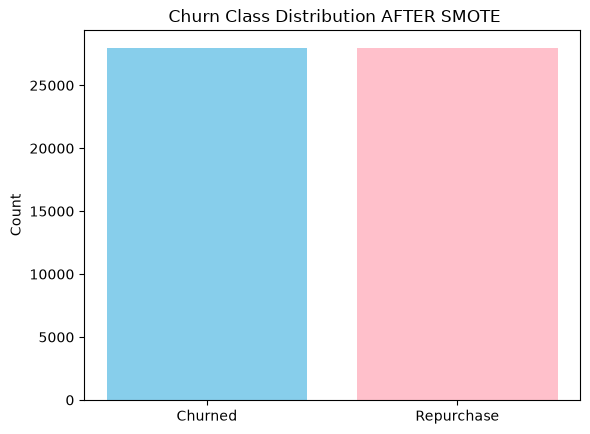

In [ ]:
smote = SMOTE(sampling_strategy="minority", random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

plt.bar(y_train_sm.value_counts().index, y_train_sm.value_counts().values, 
        color=["skyblue","pink"])
plt.xticks([0,1], ["Churned", "Repurchase"])
plt.ylabel("Count")
plt.title(" Churn Class Distribution AFTER SMOTE")
plt.show()

In [ ]:
rfcl = DecisionTreeClassifier(criterion = "gini", max_depth = 5000, random_state= 42)


rfcl.fit(X_train_sm, y_train_sm)

,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",5000
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples 

In [ ]:
ds_list = [
    ("Train", X_train_sm, y_train_sm),
    ("Val", X_val, y_val),
    ("Test", X_test, y_test)
]

for ds_name, ds_x, ds_y in ds_list:
    ds_y_pred = rfcl.predict(ds_x)

    print(ds_name)
    print('Model F1 score with gini index: {0:0.4f}'. format(f1_score(ds_y, ds_y_pred)))
    print('Model accuracy score with gini index: {0:0.4f}'. format(accuracy_score(ds_y, ds_y_pred)))

    cm = confusion_matrix(ds_y, ds_y_pred)
    print(cm)
    print()

Train
Model F1 score with gini index: 0.8475
Model accuracy score with gini index: 0.8307
[[20169  7803]
 [ 1666 26306]]

Val
Model F1 score with gini index: 0.0336
Model accuracy score with gini index: 0.7229
[[10131  3848]
 [   61    68]]

Test
Model F1 score with gini index: 0.0352
Model accuracy score with gini index: 0.7166
[[10038  3955]
 [   43    73]]



----

---

## XG Boost

In [ ]:
params = {
            'objective':'binary:logistic',
            'max_depth': 6,
            'alpha': 10,
            'learning_rate': 1.0,
            'n_estimators':100
        }
            
            
            
# instantiate the classifier 
xgb_clf = XGBClassifier(**params)



# fit the classifier to the training data
xgb_clf.fit(X_train, y_train)

,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",None
,feature_types feature_types: typing.Optional[typing.Sequence[str]].. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


In [ ]:
ds_list = [
    ("Train", X_train_sm, y_train_sm),
    ("Val", X_val, y_val),
    ("Test", X_test, y_test)
]

for ds_name, ds_x, ds_y in ds_list:
    ds_y_pred = xgb_clf.predict(ds_x)

    print(ds_name)
    print('Model F1 score with gini index: {0:0.4f}'. format(f1_score(ds_y, ds_y_pred)))
    print('Model accuracy score with gini index: {0:0.4f}'. format(accuracy_score(ds_y, ds_y_pred)))

    cm = confusion_matrix(ds_y, ds_y_pred)
    print(cm)
    print()

Train
Model F1 score with gini index: 0.0000
Model accuracy score with gini index: 0.5000
[[27972     0]
 [27972     0]]

Val
Model F1 score with gini index: 0.0000
Model accuracy score with gini index: 0.9909
[[13979     0]
 [  129     0]]

Test
Model F1 score with gini index: 0.0000
Model accuracy score with gini index: 0.9918
[[13993     0]
 [  116     0]]



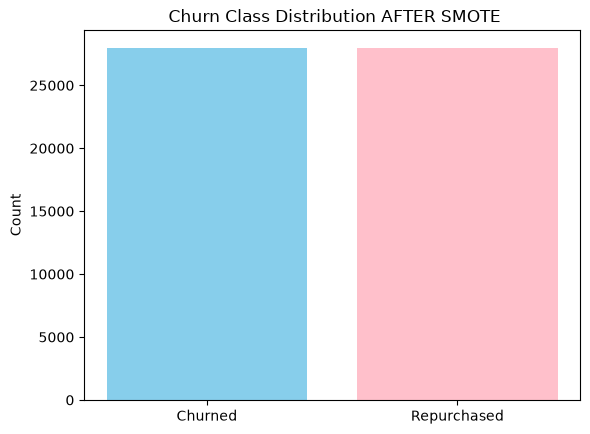

In [ ]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(sampling_strategy="minority", random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

plt.bar(y_train_sm.value_counts().index, y_train_sm.value_counts().values, 
        color=["skyblue","pink"])
plt.xticks([0,1], ["Churned", "Repurchased"])
plt.ylabel("Count")
plt.title(" Churn Class Distribution AFTER SMOTE")
plt.show()

After oversampling

In [ ]:
xgb_clf = XGBClassifier(**params)



# fit the classifier to the training data
xgb_clf.fit(X_train_sm, y_train_sm)

,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",None
,feature_types feature_types: typing.Optional[typing.Sequence[str]].. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


In [ ]:
ds_list = [
    ("Trainsm", X_train_sm, y_train_sm),
    ("Train", X_train_sm, y_train_sm),
    ("Val", X_val, y_val),
    ("Test", X_test, y_test)
]

for ds_name, ds_x, ds_y in ds_list:
    ds_y_pred = xgb_clf.predict(ds_x)

    print(ds_name)
    print('Model F1 score with gini index: {0:0.4f}'. format(f1_score(ds_y, ds_y_pred)))
    print('Model accuracy score with gini index: {0:0.4f}'. format(accuracy_score(ds_y, ds_y_pred)))

    cm = confusion_matrix(ds_y, ds_y_pred)
    print(cm)
    print()

Trainsm
Model F1 score with gini index: 0.8441
Model accuracy score with gini index: 0.8279
[[20254  7718]
 [ 1911 26061]]

Train
Model F1 score with gini index: 0.8441
Model accuracy score with gini index: 0.8279
[[20254  7718]
 [ 1911 26061]]

Val
Model F1 score with gini index: 0.0315
Model accuracy score with gini index: 0.7250
[[10165  3814]
 [   66    63]]

Test
Model F1 score with gini index: 0.0313
Model accuracy score with gini index: 0.7196
[[10089  3904]
 [   52    64]]



-----
-----

## 150 days

## 150 days train_test dataset

In [ ]:
Data_train_150_df["state_income_level"] = Data_train_150_df.customer_state.map(prov_income_map)

Data_train_150_df["state_income_level_high"] = (Data_train_150_df["state_income_level"] == "high").astype(int)
Data_train_150_df["state_income_level_mid"] = (Data_train_150_df["state_income_level"] == "mid").astype(int)
Data_train_150_df["state_income_level_low"] = (Data_train_150_df["state_income_level"] == "low").astype(int)

Data_train_150_df

,customer_unique_id,price,freight_ratio,payment_value,dates_diff,review_score,customer_city,customer_state,order_status,payment_sequential,payment_type,payment_installments,product_cat,churn_150,state_income_level,state_income_level_high,state_income_level_mid,state_income_level_low
0,0000f46a3911fa3c0805444483337064,69.00,0.249565,86.22,-2.0,3.0,sao jose,SC,delivered,1.0,credit_card,8.0,office,0,low,0,0,1
1,0005e1862207bf6ccc02e4228effd9a0,135.00,0.112000,150.12,-28.0,4.0,teresopolis,RJ,delivered,1.0,credit_card,3.0,fashion,0,high,1,0,0
2,00115fc7123b5310cf6d3a3aa932699e,59.99,0.268711,76.11,-33.0,4.0,brasilia,DF,delivered,1.0,credit_card,1.0,sports_leisure,0,low,0,0,1
3,0011805441c0d1b68b48002f1d005526,269.00,0.104610,297.14,-13.0,3.0,goianesia do para,PA,delivered,1.0,credit_card,10.0,electronics,0,low,0,0,1
4,00191a9719ef48ebb5860b130347bf33,47.90,0.228810,58.86,-19.0,3.0,jarinu,SP,delivered,1.0,credit_card,2.0,household,0,high,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
25735,fff1afc79f6b5db1e235a4a6c30ceda7,34.99,0.431552,50.09,-16.0,5.0,erechim,RS,delivered,1.0,credit_card,4.0,beauty,0,low,0,0,1
25736,fff3a9369e4b7102fab406a334a678c3,84.90,0.210130,102.74,-7.0,5.0,brasilia,DF,delivered,1.0,credit_card,2.0,fashion,0,low,0,0,1
25737,fff699c184bcc967d62fa2c6171765f7,39.90,0.378446,55.00,-7.0,4.0,santos,SP,delivered,1.0,boleto,1.0,entertainment,0,high,1,0,0
25738,fffcf5a5ff07b0908bd4e2dbc735a684,1570.00,0.320939,4134.84,-27.0,5.0,sanharo,PE,delivered,1.0,credit_card,10.0,beauty,0,mid,0,1,0


In [ ]:
Data_train_150_df["high_review_score"] = (Data_train_150_df["review_score"]>= 4).astype(int)
Data_train_150_df["medium_review_score"] = ((Data_train_150_df["review_score"]< 4) & (Data_train_150_df["review_score"]>= 2)).astype(int)
Data_train_150_df["low_review_score"] = (Data_train_150_df["review_score"]< 2).astype(int)

Data_train_150_df

,customer_unique_id,price,freight_ratio,payment_value,dates_diff,review_score,customer_city,customer_state,order_status,payment_sequential,...,payment_installments,product_cat,churn_150,state_income_level,state_income_level_high,state_income_level_mid,state_income_level_low,high_review_score,medium_review_score,low_review_score
0,0000f46a3911fa3c0805444483337064,69.00,0.249565,86.22,-2.0,3.0,sao jose,SC,delivered,1.0,...,8.0,office,0,low,0,0,1,0,1,0
1,0005e1862207bf6ccc02e4228effd9a0,135.00,0.112000,150.12,-28.0,4.0,teresopolis,RJ,delivered,1.0,...,3.0,fashion,0,high,1,0,0,1,0,0
2,00115fc7123b5310cf6d3a3aa932699e,59.99,0.268711,76.11,-33.0,4.0,brasilia,DF,delivered,1.0,...,1.0,sports_leisure,0,low,0,0,1,1,0,0
3,0011805441c0d1b68b48002f1d005526,269.00,0.104610,297.14,-13.0,3.0,goianesia do para,PA,delivered,1.0,...,10.0,electronics,0,low,0,0,1,0,1,0
4,00191a9719ef48ebb5860b130347bf33,47.90,0.228810,58.86,-19.0,3.0,jarinu,SP,delivered,1.0,...,2.0,household,0,high,1,0,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
25735,fff1afc79f6b5db1e235a4a6c30ceda7,34.99,0.431552,50.09,-16.0,5.0,erechim,RS,delivered,1.0,...,4.0,beauty,0,low,0,0,1,1,0,0
25736,fff3a9369e4b7102fab406a334a678c3,84.90,0.210130,102.74,-7.0,5.0,brasilia,DF,delivered,1.0,...,2.0,fashion,0,low,0,0,1,1,0,0
25737,fff699c184bcc967d62fa2c6171765f7,39.90,0.378446,55.00,-7.0,4.0,santos,SP,delivered,1.0,...,1.0,entertainment,0,high,1,0,0,1,0,0
25738,fffcf5a5ff07b0908bd4e2dbc735a684,1570.00,0.320939,4134.84,-27.0,5.0,sanharo,PE,delivered,1.0,...,10.0,beauty,0,mid,0,1,0,1,0,0


In [ ]:
Data_train_150_df["delay"] = (Data_train_150_df["dates_diff"]>0).astype(int)

Data_train_150_df["delay"]

0        0
1        0
2        0
3        0
4        0
        ..
25735    0
25736    0
25737    0
25738    0
25739    0
Name: delay, Length: 25740, dtype: int64

In [ ]:
Data_train_150_df["high_payment_value"] = (Data_train_150_df["payment_value"]>172.73).astype(int)

Data_train_150_df["high_payment_value"]

0        0
1        0
2        0
3        1
4        0
        ..
25735    0
25736    0
25737    0
25738    1
25739    0
Name: high_payment_value, Length: 25740, dtype: int64

In [ ]:
Data_train_150_df["expensive_freight"] = (Data_train_150_df["freight_ratio"]>0.15).astype(int)

Data_train_150_df["expensive_freight"]

0        1
1        0
2        1
3        0
4        1
        ..
25735    1
25736    1
25737    1
25738    1
25739    1
Name: expensive_freight, Length: 25740, dtype: int64

In [ ]:
Data_train_150_df["is_high_price"] = (Data_train_150_df["price"]>120.64).astype(int)

Data_train_150_df["is_high_price"]

0        0
1        1
2        0
3        1
4        0
        ..
25735    0
25736    0
25737    0
25738    1
25739    0
Name: is_high_price, Length: 25740, dtype: int64

In [ ]:
Data_train_150_df["beyond_one year"] = (Data_train_150_df["payment_installments"] > 12.0).astype(int)

Data_train_150_df["beyond_one year"]

0        0
1        0
2        0
3        0
4        0
        ..
25735    0
25736    0
25737    0
25738    0
25739    0
Name: beyond_one year, Length: 25740, dtype: int64

In [ ]:
Data_train_150_df["multiple_payment_methods"] = (Data_train_150_df["payment_sequential"] > 2.0).astype(int)

Data_train_150_df["multiple_payment_methods"]

0        0
1        0
2        0
3        0
4        0
        ..
25735    0
25736    0
25737    0
25738    0
25739    0
Name: multiple_payment_methods, Length: 25740, dtype: int64

In [ ]:
target_features = ["order_status", "payment_type", "product_cat"]

col_trans = ColumnTransformer(
    transformers=[("cat", OneHotEncoder(sparse_output= False, drop= "first", handle_unknown="ignore"), target_features)], remainder="passthrough"
)
col_trans.fit(Data_train_150_df)

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'passthrough'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_name``. e.g. 

In [ ]:
encoded_array = col_trans.transform(Data_train_150_df)

In [ ]:
encoded_150_df = pd.DataFrame(encoded_array, columns= col_trans.get_feature_names_out(Data_train_150_df.columns))

encoded_150_df

,cat__order_status_canceled,cat__order_status_delivered,cat__order_status_invoiced,cat__order_status_processing,cat__order_status_shipped,cat__payment_type_credit_card,cat__payment_type_debit_card,cat__payment_type_voucher,cat__product_cat_babies,cat__product_cat_beauty,...,remainder__state_income_level_low,remainder__high_review_score,remainder__medium_review_score,remainder__low_review_score,remainder__delay,remainder__high_payment_value,remainder__expensive_freight,remainder__is_high_price,remainder__beyond_one year,remainder__multiple_payment_methods
0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,1,0,1,0,0,0,1,0,0,0
1,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,0,1,0,0,0,0,0,1,0,0
2,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,1,1,0,0,0,0,1,0,0,0
3,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,1,0,1,0,0,1,0,1,0,0
4,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,0,0,1,0,0,0,1,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
25735,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,...,1,1,0,0,0,0,1,0,0,0
25736,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,1,1,0,0,0,0,1,0,0,0
25737,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0,1,0,0,0,0,1,0,0,0
25738,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,...,0,1,0,0,0,1,1,1,0,0


In [ ]:
encoded_150_df.columns = encoded_150_df.columns.str.replace('remainder__', '')

encoded_150_df

,cat__order_status_canceled,cat__order_status_delivered,cat__order_status_invoiced,cat__order_status_processing,cat__order_status_shipped,cat__payment_type_credit_card,cat__payment_type_debit_card,cat__payment_type_voucher,cat__product_cat_babies,cat__product_cat_beauty,...,state_income_level_low,high_review_score,medium_review_score,low_review_score,delay,high_payment_value,expensive_freight,is_high_price,beyond_one year,multiple_payment_methods
0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,1,0,1,0,0,0,1,0,0,0
1,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,0,1,0,0,0,0,0,1,0,0
2,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,1,1,0,0,0,0,1,0,0,0
3,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,1,0,1,0,0,1,0,1,0,0
4,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,0,0,1,0,0,0,1,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
25735,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,...,1,1,0,0,0,0,1,0,0,0
25736,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,1,1,0,0,0,0,1,0,0,0
25737,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0,1,0,0,0,0,1,0,0,0
25738,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,...,0,1,0,0,0,1,1,1,0,0


----

## Test dataset

In [ ]:
Data_test_150_df

,customer_unique_id,price,freight_ratio,payment_value,dates_diff,review_score,customer_city,customer_state,order_status,payment_sequential,payment_type,payment_installments,product_cat,churn_150
0,0000366f3b9a7992bf8c76cfdf3221e2,129.90,0.092379,141.90,-5.0,5.0,cajamar,SP,delivered,1.0,credit_card,8.0,household,0
1,0000b849f77a49e4a4ce2b2a4ca5be3f,18.90,0.438624,27.19,-5.0,4.0,osasco,SP,delivered,1.0,credit_card,1.0,beauty,0
2,0004bd2a26a76fe21f786e4fbd80607f,154.00,0.084286,166.98,-12.0,4.0,sao paulo,SP,delivered,1.0,credit_card,8.0,miscellaneous,0
3,00050ab1314c0e55a6ca13cf7181fecf,27.99,0.264023,35.38,-12.0,4.0,campinas,SP,delivered,1.0,boleto,1.0,electronics,0
4,00053a61a98854899e70ed204dd4bafe,382.00,0.097330,838.36,-10.0,1.0,curitiba,PR,delivered,1.0,credit_card,3.0,sports_leisure,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
33672,ffeddf8aa7cdecf403e77b2e9a99e2ea,330.00,0.237576,204.20,6.0,2.0,santarem,PA,delivered,2.0,credit_card,5.0,office,0
33673,fff1bdd5c5e37ca79dd74deeb91aa5b6,134.90,0.282283,172.98,32.0,1.0,araguaina,TO,delivered,2.0,debit_card,1.0,entertainment,0
33674,fff2ae16b99c6f3c785f0e052f2a9cfb,129.94,0.546098,200.90,-21.0,5.0,rio de janeiro,RJ,delivered,1.0,credit_card,8.0,office,0
33675,fffcc512b7dfecaffd80f13614af1d16,688.00,0.032994,710.70,0.0,1.0,cabo frio,RJ,shipped,1.0,credit_card,3.0,beauty,0


In [ ]:
Data_test_150_df["state_income_level"] = Data_test_150_df.customer_state.map(prov_income_map)

Data_test_150_df["state_income_level_high"] = (Data_test_150_df["state_income_level"] == "high").astype(int)
Data_test_150_df["state_income_level_mid"] = (Data_test_150_df["state_income_level"] == "mid").astype(int)
Data_test_150_df["state_income_level_low"] = (Data_test_150_df["state_income_level"] == "low").astype(int)

Data_test_150_df 

,customer_unique_id,price,freight_ratio,payment_value,dates_diff,review_score,customer_city,customer_state,order_status,payment_sequential,payment_type,payment_installments,product_cat,churn_150,state_income_level,state_income_level_high,state_income_level_mid,state_income_level_low
0,0000366f3b9a7992bf8c76cfdf3221e2,129.90,0.092379,141.90,-5.0,5.0,cajamar,SP,delivered,1.0,credit_card,8.0,household,0,high,1,0,0
1,0000b849f77a49e4a4ce2b2a4ca5be3f,18.90,0.438624,27.19,-5.0,4.0,osasco,SP,delivered,1.0,credit_card,1.0,beauty,0,high,1,0,0
2,0004bd2a26a76fe21f786e4fbd80607f,154.00,0.084286,166.98,-12.0,4.0,sao paulo,SP,delivered,1.0,credit_card,8.0,miscellaneous,0,high,1,0,0
3,00050ab1314c0e55a6ca13cf7181fecf,27.99,0.264023,35.38,-12.0,4.0,campinas,SP,delivered,1.0,boleto,1.0,electronics,0,high,1,0,0
4,00053a61a98854899e70ed204dd4bafe,382.00,0.097330,838.36,-10.0,1.0,curitiba,PR,delivered,1.0,credit_card,3.0,sports_leisure,0,low,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
33672,ffeddf8aa7cdecf403e77b2e9a99e2ea,330.00,0.237576,204.20,6.0,2.0,santarem,PA,delivered,2.0,credit_card,5.0,office,0,low,0,0,1
33673,fff1bdd5c5e37ca79dd74deeb91aa5b6,134.90,0.282283,172.98,32.0,1.0,araguaina,TO,delivered,2.0,debit_card,1.0,entertainment,0,low,0,0,1
33674,fff2ae16b99c6f3c785f0e052f2a9cfb,129.94,0.546098,200.90,-21.0,5.0,rio de janeiro,RJ,delivered,1.0,credit_card,8.0,office,0,high,1,0,0
33675,fffcc512b7dfecaffd80f13614af1d16,688.00,0.032994,710.70,0.0,1.0,cabo frio,RJ,shipped,1.0,credit_card,3.0,beauty,0,high,1,0,0


In [ ]:
Data_test_150_df["high_review_score"] = (Data_test_150_df["review_score"]>= 4).astype(int)
Data_test_150_df["medium_review_score"] = ((Data_test_150_df["review_score"]< 4) & (Data_test_150_df["review_score"]>= 2)).astype(int)
Data_test_150_df["low_review_score"] = (Data_test_150_df["review_score"]< 2).astype(int)

Data_test_150_df

,customer_unique_id,price,freight_ratio,payment_value,dates_diff,review_score,customer_city,customer_state,order_status,payment_sequential,...,payment_installments,product_cat,churn_150,state_income_level,state_income_level_high,state_income_level_mid,state_income_level_low,high_review_score,medium_review_score,low_review_score
0,0000366f3b9a7992bf8c76cfdf3221e2,129.90,0.092379,141.90,-5.0,5.0,cajamar,SP,delivered,1.0,...,8.0,household,0,high,1,0,0,1,0,0
1,0000b849f77a49e4a4ce2b2a4ca5be3f,18.90,0.438624,27.19,-5.0,4.0,osasco,SP,delivered,1.0,...,1.0,beauty,0,high,1,0,0,1,0,0
2,0004bd2a26a76fe21f786e4fbd80607f,154.00,0.084286,166.98,-12.0,4.0,sao paulo,SP,delivered,1.0,...,8.0,miscellaneous,0,high,1,0,0,1,0,0
3,00050ab1314c0e55a6ca13cf7181fecf,27.99,0.264023,35.38,-12.0,4.0,campinas,SP,delivered,1.0,...,1.0,electronics,0,high,1,0,0,1,0,0
4,00053a61a98854899e70ed204dd4bafe,382.00,0.097330,838.36,-10.0,1.0,curitiba,PR,delivered,1.0,...,3.0,sports_leisure,0,low,0,0,1,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
33672,ffeddf8aa7cdecf403e77b2e9a99e2ea,330.00,0.237576,204.20,6.0,2.0,santarem,PA,delivered,2.0,...,5.0,office,0,low,0,0,1,0,1,0
33673,fff1bdd5c5e37ca79dd74deeb91aa5b6,134.90,0.282283,172.98,32.0,1.0,araguaina,TO,delivered,2.0,...,1.0,entertainment,0,low,0,0,1,0,0,1
33674,fff2ae16b99c6f3c785f0e052f2a9cfb,129.94,0.546098,200.90,-21.0,5.0,rio de janeiro,RJ,delivered,1.0,...,8.0,office,0,high,1,0,0,1,0,0
33675,fffcc512b7dfecaffd80f13614af1d16,688.00,0.032994,710.70,0.0,1.0,cabo frio,RJ,shipped,1.0,...,3.0,beauty,0,high,1,0,0,0,0,1


In [ ]:
Data_test_150_df["delay"] = (Data_test_150_df["dates_diff"]>0).astype(int)

Data_test_150_df["delay"]

0        0
1        0
2        0
3        0
4        0
        ..
33672    1
33673    1
33674    0
33675    0
33676    0
Name: delay, Length: 33677, dtype: int64

In [ ]:
Data_test_150_df["high_payment_value"] = (Data_test_150_df["payment_value"]>172.73).astype(int)

Data_test_150_df["high_payment_value"]

0        0
1        0
2        0
3        0
4        1
        ..
33672    1
33673    1
33674    1
33675    1
33676    0
Name: high_payment_value, Length: 33677, dtype: int64

In [ ]:
Data_test_150_df["expensive_freight"] = (Data_test_150_df["freight_ratio"]>20.03).astype(int)

Data_test_150_df["expensive_freight"]

0        0
1        0
2        0
3        0
4        0
        ..
33672    0
33673    0
33674    0
33675    0
33676    0
Name: expensive_freight, Length: 33677, dtype: int64

In [ ]:
Data_test_150_df["is_high_price"] = (Data_test_150_df["price"]>120.64).astype(int)

Data_test_150_df["is_high_price"]

0        1
1        0
2        1
3        0
4        1
        ..
33672    1
33673    1
33674    1
33675    1
33676    0
Name: is_high_price, Length: 33677, dtype: int64

In [ ]:
Data_test_150_df["beyond_one year"] = (Data_test_150_df["payment_installments"] > 12.0).astype(int)

Data_test_150_df["beyond_one year"]

0        0
1        0
2        0
3        0
4        0
        ..
33672    0
33673    0
33674    0
33675    0
33676    0
Name: beyond_one year, Length: 33677, dtype: int64

In [ ]:
Data_test_150_df["multiple_payment_methods"] = (Data_test_150_df["payment_sequential"] > 2.0).astype(int)

Data_test_150_df["multiple_payment_methods"]

0        0
1        0
2        0
3        0
4        0
        ..
33672    0
33673    0
33674    0
33675    0
33676    0
Name: multiple_payment_methods, Length: 33677, dtype: int64

In [ ]:
encoded_array_test = col_trans.transform(Data_test_150_df)

In [ ]:
encoded_150_test_df = pd.DataFrame(encoded_array_test, columns= col_trans.get_feature_names_out(Data_test_150_df.columns))

encoded_150_test_df

,cat__order_status_canceled,cat__order_status_delivered,cat__order_status_invoiced,cat__order_status_processing,cat__order_status_shipped,cat__payment_type_credit_card,cat__payment_type_debit_card,cat__payment_type_voucher,cat__product_cat_babies,cat__product_cat_beauty,...,remainder__state_income_level_low,remainder__high_review_score,remainder__medium_review_score,remainder__low_review_score,remainder__delay,remainder__high_payment_value,remainder__expensive_freight,remainder__is_high_price,remainder__beyond_one year,remainder__multiple_payment_methods
0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,0,1,0,0,0,0,0,1,0,0
1,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,...,0,1,0,0,0,0,0,0,0,0
2,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,0,1,0,0,0,0,0,1,0,0
3,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0,1,0,0,0,0,0,0,0,0
4,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,1,0,0,1,0,1,0,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
33672,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,1,0,1,0,1,1,0,1,0,0
33673,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,1,0,0,1,1,1,0,1,0,0
33674,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,0,1,0,0,0,1,0,1,0,0
33675,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,...,0,0,0,1,0,1,0,1,0,0


In [ ]:
encoded_150_test_df.columns = encoded_150_test_df.columns.str.replace('remainder__', '')

encoded_150_test_df

,cat__order_status_canceled,cat__order_status_delivered,cat__order_status_invoiced,cat__order_status_processing,cat__order_status_shipped,cat__payment_type_credit_card,cat__payment_type_debit_card,cat__payment_type_voucher,cat__product_cat_babies,cat__product_cat_beauty,...,state_income_level_low,high_review_score,medium_review_score,low_review_score,delay,high_payment_value,expensive_freight,is_high_price,beyond_one year,multiple_payment_methods
0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,0,1,0,0,0,0,0,1,0,0
1,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,...,0,1,0,0,0,0,0,0,0,0
2,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,0,1,0,0,0,0,0,1,0,0
3,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0,1,0,0,0,0,0,0,0,0
4,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,1,0,0,1,0,1,0,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
33672,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,1,0,1,0,1,1,0,1,0,0
33673,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,1,0,0,1,1,1,0,1,0,0
33674,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,0,1,0,0,0,1,0,1,0,0
33675,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,...,0,0,0,1,0,1,0,1,0,0


-----

## Train test split

In [ ]:
X_train = encoded_150_df.drop(columns = ['churn_150', "customer_unique_id", "customer_city", "customer_state",	"payment_sequential", "payment_installments",	"state_income_level", "price", "freight_ratio", "payment_value", "dates_diff",	"review_score"])

y_train = encoded_150_df['churn_150'].fillna(0).astype(int)

In [ ]:
X_valtest = encoded_150_test_df.drop(columns = ['churn_150', "customer_unique_id", "customer_city", "customer_state",	"payment_sequential", "payment_installments",	"state_income_level", "price", "freight_ratio", "payment_value", "dates_diff",	"review_score"])

y_valtest = encoded_150_test_df['churn_150'].fillna(0).astype(int)

In [ ]:
X_val, X_test, y_val, y_test  =  train_test_split(X_valtest, y_valtest, test_size= 0.5, random_state = 42)

In [ ]:
print(X_train.shape)
print(X_valtest.shape)

(25740, 35)
(33677, 35)


In [ ]:
X_train = X_train.astype(int)

X_val = X_val.astype(int)

X_test = X_test.astype(int)

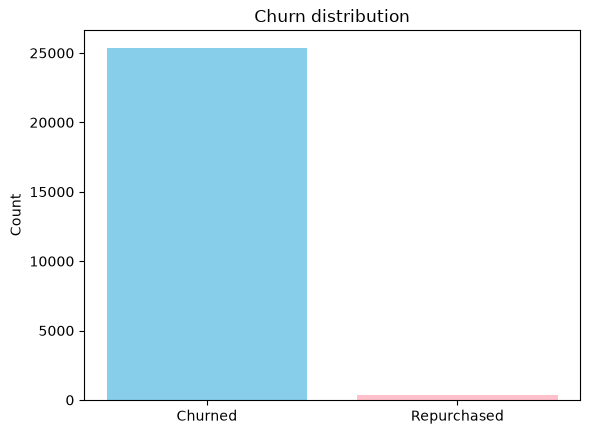

In [ ]:
plt.bar(y_train.value_counts().index, y_train.value_counts().values, color=['skyblue','pink'])
plt.xticks([0,1], ["Churned", "Repurchased"])
plt.ylabel("Count")
plt.title("Churn distribution")
plt.show()

----

## Logistic regression

In [ ]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression( random_state= 42)


# fit the model
lr.fit(X_train, y_train)

,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",42
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solve

In [ ]:
pd.DataFrame(list(zip(X_train.columns, lr.coef_[0])), columns= ["Feature_name", "Coefficient"])

,Feature_name,Coefficient
0,cat__order_status_canceled,-0.074476
1,cat__order_status_delivered,0.561072
2,cat__order_status_invoiced,-0.623198
3,cat__order_status_processing,-0.852018
4,cat__order_status_shipped,-1.401098
5,cat__payment_type_credit_card,0.000944
6,cat__payment_type_debit_card,0.379319
7,cat__payment_type_voucher,0.090209
8,cat__product_cat_babies,-0.010295
9,cat__product_cat_beauty,0.117682


In [ ]:
import statsmodels.api as stm

model_stm = stm.Logit(y_train, X_train).fit()

print(model_stm.summary())

         Current function value: 0.075361
         Iterations: 35


c:\Users\Hallen\anaconda3\envs\silv_env\Lib\site-packages\statsmodels\discrete\discrete_model.py:268: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  mlefit = super().fit(


                           Logit Regression Results                           
Dep. Variable:              churn_150   No. Observations:                25740
Model:                          Logit   Df Residuals:                    25706
Method:                           MLE   Df Model:                           33
Date:                Sun, 13 Sep 2026   Pseudo R-squ.:                 0.01569
Time:                        13:38:18   Log-Likelihood:                -1939.8
converged:                      False   LL-Null:                       -1970.7
Covariance Type:            nonrobust   LLR p-value:                  0.001712
                                             coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------------------------
cat__order_status_canceled                12.8191   3451.370      0.004      0.997   -6751.742    6777.380
cat__order_status_delivered               12.88

In [ ]:
ds_list = [
    ("Train", X_train, y_train),
    ("Val", X_val, y_val),
    ("Test", X_test, y_test)
]

for ds_name, ds_x, ds_y in ds_list:
    ds_y_pred = lr.predict(ds_x)

    print(ds_name)
    print('Model F1 score with gini index: {0:0.4f}'. format(f1_score(ds_y, ds_y_pred)))
    print('Model accuracy score with gini index: {0:0.4f}'. format(accuracy_score(ds_y, ds_y_pred)))

    cm = confusion_matrix(ds_y, ds_y_pred)
    print(cm)
    print()


Train
Model F1 score with gini index: 0.0000
Model accuracy score with gini index: 0.9853
[[25362     0]
 [  378     0]]

Val
Model F1 score with gini index: 0.0000
Model accuracy score with gini index: 0.9943
[[16742     0]
 [   96     0]]

Test
Model F1 score with gini index: 0.0000
Model accuracy score with gini index: 0.9939
[[16737     0]
 [  102     0]]



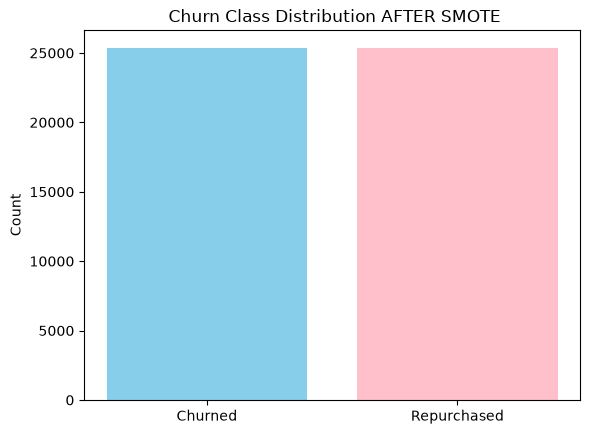

In [ ]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(sampling_strategy="minority", random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

plt.bar(y_train_sm.value_counts().index, y_train_sm.value_counts().values, 
        color=["skyblue","pink"])
plt.xticks([0,1], ["Churned", "Repurchased"])
plt.ylabel("Count")
plt.title(" Churn Class Distribution AFTER SMOTE")
plt.show()

In [ ]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression( random_state= 42)


# fit the model
lr.fit(X_train_sm, y_train_sm)

c:\Users\Hallen\anaconda3\envs\silv_env\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",42
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solve

In [ ]:
pd.DataFrame(list(zip(X_train.columns, lr.coef_[0])), columns= ["Feature_name", "Coefficient"])

,Feature_name,Coefficient
0,cat__order_status_canceled,-2.076987
1,cat__order_status_delivered,-1.132461
2,cat__order_status_invoiced,-3.049734
3,cat__order_status_processing,-3.761164
4,cat__order_status_shipped,-4.516689
5,cat__payment_type_credit_card,-0.382634
6,cat__payment_type_debit_card,-2.576408
7,cat__payment_type_voucher,-1.792999
8,cat__product_cat_babies,-3.275178
9,cat__product_cat_beauty,-2.148133


In [ ]:
import statsmodels.api as stm

model_stm = stm.Logit(y_train, X_train).fit()

print(model_stm.summary())

         Current function value: 0.075361
         Iterations: 35


c:\Users\Hallen\anaconda3\envs\silv_env\Lib\site-packages\statsmodels\discrete\discrete_model.py:268: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  mlefit = super().fit(


                           Logit Regression Results                           
Dep. Variable:              churn_150   No. Observations:                25740
Model:                          Logit   Df Residuals:                    25706
Method:                           MLE   Df Model:                           33
Date:                Sun, 13 Sep 2026   Pseudo R-squ.:                 0.01569
Time:                        13:38:21   Log-Likelihood:                -1939.8
converged:                      False   LL-Null:                       -1970.7
Covariance Type:            nonrobust   LLR p-value:                  0.001712
                                             coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------------------------
cat__order_status_canceled                12.8191   3451.370      0.004      0.997   -6751.742    6777.380
cat__order_status_delivered               12.88

In [ ]:
ds_list = [
    ("Train", X_train, y_train),
    ("Val", X_val, y_val),
    ("Test", X_test, y_test)
]

for ds_name, ds_x, ds_y in ds_list:
    ds_y_pred = lr.predict(ds_x)

    print(ds_name)
    print('Model F1 score with gini index: {0:0.4f}'. format(f1_score(ds_y, ds_y_pred)))
    print('Model accuracy score with gini index: {0:0.4f}'. format(accuracy_score(ds_y, ds_y_pred)))

    cm = confusion_matrix(ds_y, ds_y_pred)
    print(cm)
    print()

Train
Model F1 score with gini index: 0.0325
Model accuracy score with gini index: 0.6581
[[16792  8570]
 [  230   148]]

Val
Model F1 score with gini index: 0.0138
Model accuracy score with gini index: 0.5834
[[9775 6967]
 [  47   49]]

Test
Model F1 score with gini index: 0.0129
Model accuracy score with gini index: 0.5895
[[9881 6856]
 [  57   45]]



----

# Gini Criterion

## Decision Tree

In [ ]:
clf = DecisionTreeClassifier(criterion = "gini", max_depth = 5000, random_state= 42)


clf.fit(X_train, y_train)

,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",5000
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples 

In [ ]:
ds_list = [
    ("Train", X_train, y_train),
    ("Val", X_val, y_val),
    ("Test", X_test, y_test)
]

for ds_name, ds_x, ds_y in ds_list:
    ds_y_pred = clf.predict(ds_x)

    print(ds_name)
    print('Model F1 score with gini index: {0:0.4f}'. format(f1_score(ds_y, ds_y_pred)))
    print('Model accuracy score with gini index: {0:0.4f}'. format(accuracy_score(ds_y, ds_y_pred)))

    cm = confusion_matrix(ds_y, ds_y_pred)
    print(cm)
    print()

Train
Model F1 score with gini index: 0.0957
Model accuracy score with gini index: 0.9861
[[25362     0]
 [  359    19]]

Val
Model F1 score with gini index: 0.0230
Model accuracy score with gini index: 0.9899
[[16666    76]
 [   94     2]]

Test
Model F1 score with gini index: 0.0000
Model accuracy score with gini index: 0.9883
[[16642    95]
 [  102     0]]



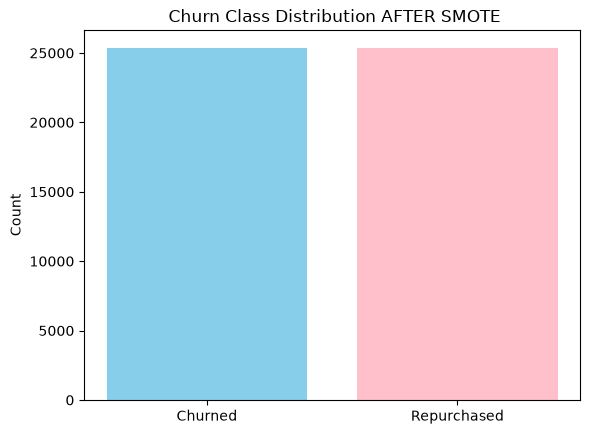

In [ ]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(sampling_strategy="minority", random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

plt.bar(y_train_sm.value_counts().index, y_train_sm.value_counts().values, 
        color=["skyblue","pink"])
plt.xticks([0,1], ["Churned", "Repurchased"])
plt.ylabel("Count")
plt.title(" Churn Class Distribution AFTER SMOTE")
plt.show()

In [ ]:
clf = DecisionTreeClassifier(criterion = "gini", max_depth = 5000, random_state= 42)


clf.fit(X_train_sm, y_train_sm)

,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",5000
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples 

In [ ]:
s_list = [
    ("Train", X_train_sm, y_train_sm),
    ("Val", X_val, y_val),
    ("Test", X_test, y_test)
]

for ds_name, ds_x, ds_y in ds_list:
    ds_y_pred = clf.predict(ds_x)

    print(ds_name)
    print('Model F1 score with gini index: {0:0.4f}'. format(f1_score(ds_y, ds_y_pred)))
    print('Model accuracy score with gini index: {0:0.4f}'. format(accuracy_score(ds_y, ds_y_pred)))

    cm = confusion_matrix(ds_y, ds_y_pred)
    print(cm)
    print()


Train
Model F1 score with gini index: 0.0500
Model accuracy score with gini index: 0.6340
[[16070  9292]
 [  130   248]]

Val
Model F1 score with gini index: 0.0132
Model accuracy score with gini index: 0.7168
[[12037  4705]
 [   64    32]]

Test
Model F1 score with gini index: 0.0160
Model accuracy score with gini index: 0.7220
[[12120  4617]
 [   64    38]]



-----

# Random Forest

In [ ]:
rfcl = RandomForestClassifier(criterion= "gini", n_estimators=300, 
                               random_state=42, 
                               max_features = 'sqrt',
                               n_jobs=-1, verbose = 1)

# Fit on training data
rfcl.fit(X_train, y_train)

[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 8 concurrent workers.
[Parallel(n_jobs=-1)]: Done  34 tasks      | elapsed:    0.4s
[Parallel(n_jobs=-1)]: Done 184 tasks      | elapsed:    2.2s
[Parallel(n_jobs=-1)]: Done 300 out of 300 | elapsed:    3.5s finished


,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",300
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel. :meth:`fit`, :meth:`predict`,:meth:`decision_path` and :meth:`apply` are all parallelized over thetrees. ``None`` means 1 unless in a :obj:`joblib.parallel_backend`context. ``-1`` means using all processors. See :term:`Glossary<n_jobs>` for more details.",-1
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"verbose verbose: int, default=0Controls the verbosity when fitting and predicting.",1
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None


In [ ]:
train_rf_predictions = rfcl.predict(X_train)
train_rf_probs = rfcl.predict_proba(X_train)

rf_predictions = rfcl.predict(X_test)
rf_probs = rfcl.predict_proba(X_test)

[Parallel(n_jobs=8)]: Using backend ThreadingBackend with 8 concurrent workers.
[Parallel(n_jobs=8)]: Done  34 tasks      | elapsed:    0.0s
[Parallel(n_jobs=8)]: Done 184 tasks      | elapsed:    0.3s
[Parallel(n_jobs=8)]: Done 300 out of 300 | elapsed:    0.6s finished
[Parallel(n_jobs=8)]: Using backend ThreadingBackend with 8 concurrent workers.
[Parallel(n_jobs=8)]: Done  34 tasks      | elapsed:    0.0s
[Parallel(n_jobs=8)]: Done 184 tasks      | elapsed:    0.4s
[Parallel(n_jobs=8)]: Done 300 out of 300 | elapsed:    0.6s finished
[Parallel(n_jobs=8)]: Using backend ThreadingBackend with 8 concurrent workers.
[Parallel(n_jobs=8)]: Done  34 tasks      | elapsed:    0.0s
[Parallel(n_jobs=8)]: Done 184 tasks      | elapsed:    0.3s
[Parallel(n_jobs=8)]: Done 300 out of 300 | elapsed:    0.5s finished
[Parallel(n_jobs=8)]: Using backend ThreadingBackend with 8 concurrent workers.
[Parallel(n_jobs=8)]: Done  34 tasks      | elapsed:    0.0s
[Parallel(n_jobs=8)]: Done 184 tasks      |

In [ ]:
y_pred = rfcl.predict(X_test)

[Parallel(n_jobs=8)]: Using backend ThreadingBackend with 8 concurrent workers.
[Parallel(n_jobs=8)]: Done  34 tasks      | elapsed:    0.0s
[Parallel(n_jobs=8)]: Done 184 tasks      | elapsed:    0.3s
[Parallel(n_jobs=8)]: Done 300 out of 300 | elapsed:    0.5s finished


In [ ]:
print('Model accuracy score with 10 decision-trees : {0:0.4f}'. format(accuracy_score(y_test, y_pred)))

Model accuracy score with 10 decision-trees : 0.9925


In [ ]:
cm = confusion_matrix(y_test, y_pred)
cm

array([[16713,    24],
       [  102,     0]])

In [ ]:
ds_list = [
    ("Train", X_train_sm, y_train_sm),
    ("Val", X_val, y_val),
    ("Test", X_test, y_test)
]

for ds_name, ds_x, ds_y in ds_list:
    ds_y_pred = rfcl.predict(ds_x)

    print(ds_name)
    print('Model F1 score with gini index: {0:0.4f}'. format(f1_score(ds_y, ds_y_pred)))
    print('Model accuracy score with gini index: {0:0.4f}'. format(accuracy_score(ds_y, ds_y_pred)))

    cm = confusion_matrix(ds_y, ds_y_pred)
    print(cm)
    print()

[Parallel(n_jobs=8)]: Using backend ThreadingBackend with 8 concurrent workers.
[Parallel(n_jobs=8)]: Done  34 tasks      | elapsed:    0.1s
[Parallel(n_jobs=8)]: Done 184 tasks      | elapsed:    1.0s
[Parallel(n_jobs=8)]: Done 300 out of 300 | elapsed:    1.6s finished
[Parallel(n_jobs=8)]: Using backend ThreadingBackend with 8 concurrent workers.
[Parallel(n_jobs=8)]: Done  34 tasks      | elapsed:    0.0s


Train
Model F1 score with gini index: 0.0271
Model accuracy score with gini index: 0.5069
[[25362     0]
 [25014   348]]



[Parallel(n_jobs=8)]: Done 184 tasks      | elapsed:    0.3s
[Parallel(n_jobs=8)]: Done 300 out of 300 | elapsed:    0.5s finished
[Parallel(n_jobs=8)]: Using backend ThreadingBackend with 8 concurrent workers.
[Parallel(n_jobs=8)]: Done  34 tasks      | elapsed:    0.0s


Val
Model F1 score with gini index: 0.0177
Model accuracy score with gini index: 0.9934
[[16726    16]
 [   95     1]]



[Parallel(n_jobs=8)]: Done 184 tasks      | elapsed:    0.3s


Test
Model F1 score with gini index: 0.0000
Model accuracy score with gini index: 0.9925
[[16713    24]
 [  102     0]]



[Parallel(n_jobs=8)]: Done 300 out of 300 | elapsed:    0.5s finished


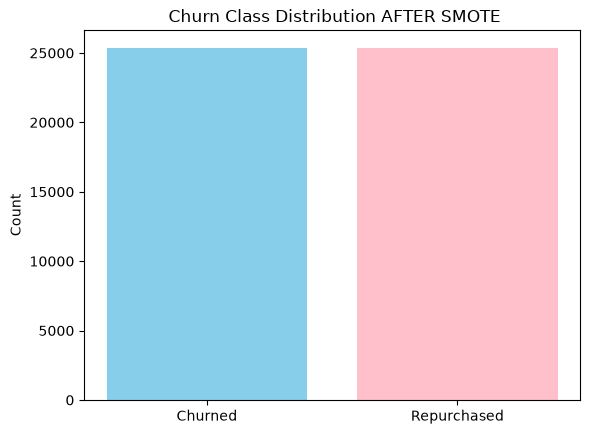

In [ ]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(sampling_strategy="minority", random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

plt.bar(y_train_sm.value_counts().index, y_train_sm.value_counts().values, 
        color=["skyblue","pink"])
plt.xticks([0,1], ["Churned", "Repurchased"])
plt.ylabel("Count")
plt.title(" Churn Class Distribution AFTER SMOTE")
plt.show()

After oversampling

In [ ]:
rfcl = RandomForestClassifier(criterion= "gini", n_estimators=300, 
                               random_state=42, 
                               max_features = 'sqrt',
                               n_jobs=-1, verbose = 1)

# Fit on training data
rfcl.fit(X_train_sm, y_train_sm)

[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 8 concurrent workers.
[Parallel(n_jobs=-1)]: Done  34 tasks      | elapsed:    1.4s
[Parallel(n_jobs=-1)]: Done 184 tasks      | elapsed:    6.2s
[Parallel(n_jobs=-1)]: Done 300 out of 300 | elapsed:   10.9s finished


,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",300
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel. :meth:`fit`, :meth:`predict`,:meth:`decision_path` and :meth:`apply` are all parallelized over thetrees. ``None`` means 1 unless in a :obj:`joblib.parallel_backend`context. ``-1`` means using all processors. See :term:`Glossary<n_jobs>` for more details.",-1
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"verbose verbose: int, default=0Controls the verbosity when fitting and predicting.",1
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None


In [ ]:
ds_list = [
    ("Train", X_train_sm, y_train_sm),
    ("Val", X_val, y_val),
    ("Test", X_test, y_test)
]

for ds_name, ds_x, ds_y in ds_list:
    ds_y_pred = rfcl.predict(ds_x)

    print(ds_name)
    print('Model F1 score with gini index: {0:0.4f}'. format(f1_score(ds_y, ds_y_pred)))
    print('Model accuracy score with gini index: {0:0.4f}'. format(accuracy_score(ds_y, ds_y_pred)))

    cm = confusion_matrix(ds_y, ds_y_pred)
    print(cm)
    print()


[Parallel(n_jobs=8)]: Using backend ThreadingBackend with 8 concurrent workers.
[Parallel(n_jobs=8)]: Done  34 tasks      | elapsed:    0.5s
[Parallel(n_jobs=8)]: Done 184 tasks      | elapsed:    1.4s
[Parallel(n_jobs=8)]: Done 300 out of 300 | elapsed:    2.1s finished
[Parallel(n_jobs=8)]: Using backend ThreadingBackend with 8 concurrent workers.


Train
Model F1 score with gini index: 0.7808
Model accuracy score with gini index: 0.7544
[[16069  9293]
 [ 3166 22196]]



[Parallel(n_jobs=8)]: Done  34 tasks      | elapsed:    0.0s
[Parallel(n_jobs=8)]: Done 184 tasks      | elapsed:    0.4s
[Parallel(n_jobs=8)]: Done 300 out of 300 | elapsed:    0.7s finished
[Parallel(n_jobs=8)]: Using backend ThreadingBackend with 8 concurrent workers.


Val
Model F1 score with gini index: 0.0136
Model accuracy score with gini index: 0.7322
[[12297  4445]
 [   65    31]]



[Parallel(n_jobs=8)]: Done  34 tasks      | elapsed:    0.1s
[Parallel(n_jobs=8)]: Done 184 tasks      | elapsed:    0.5s


Test
Model F1 score with gini index: 0.0164
Model accuracy score with gini index: 0.7363
[[12361  4376]
 [   65    37]]



[Parallel(n_jobs=8)]: Done 300 out of 300 | elapsed:    0.9s finished


---

## XG Boost

In [ ]:
params = {
            'objective':'binary:logistic',
            'max_depth': 6,
            'alpha': 10,
            'learning_rate': 1.0,
            'n_estimators':100
        }
            
            
            
# instantiate the classifier 
xgb_clf = XGBClassifier(**params)



# fit the classifier to the training data
xgb_clf.fit(X_train, y_train)

,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",None
,feature_types feature_types: typing.Optional[typing.Sequence[str]].. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


In [ ]:
ds_list = [
    ("Train", X_train_sm, y_train_sm),
    ("Val", X_val, y_val),
    ("Test", X_test, y_test)
]

for ds_name, ds_x, ds_y in ds_list:
    ds_y_pred = xgb_clf.predict(ds_x)

    print(ds_name)
    print('Model F1 score with gini index: {0:0.4f}'. format(f1_score(ds_y, ds_y_pred)))
    print('Model accuracy score with gini index: {0:0.4f}'. format(accuracy_score(ds_y, ds_y_pred)))

    cm = confusion_matrix(ds_y, ds_y_pred)
    print(cm)
    print()

Train
Model F1 score with gini index: 0.0000
Model accuracy score with gini index: 0.5000
[[25362     0]
 [25362     0]]

Val
Model F1 score with gini index: 0.0000
Model accuracy score with gini index: 0.9943
[[16742     0]
 [   96     0]]

Test
Model F1 score with gini index: 0.0000
Model accuracy score with gini index: 0.9939
[[16737     0]
 [  102     0]]



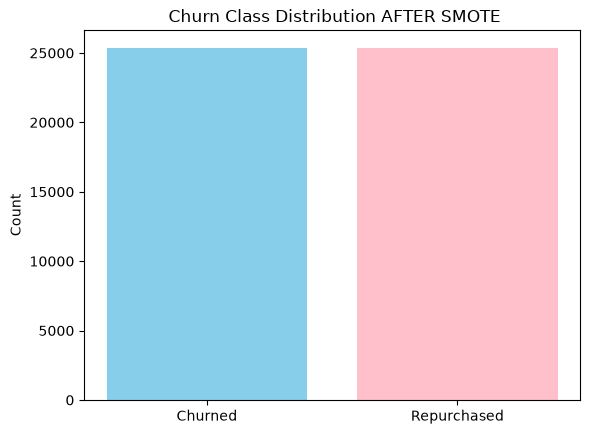

In [ ]:
smote = SMOTE(sampling_strategy="minority", random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

plt.bar(y_train_sm.value_counts().index, y_train_sm.value_counts().values, 
        color=["skyblue","pink"])
plt.xticks([0,1], ["Churned", "Repurchased"])
plt.ylabel("Count")
plt.title(" Churn Class Distribution AFTER SMOTE")
plt.show()

After oversample

In [ ]:
xgb_clf = XGBClassifier(**params)



# fit the classifier to the training data
xgb_clf.fit(X_train_sm, y_train_sm)

,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",None
,feature_types feature_types: typing.Optional[typing.Sequence[str]].. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


In [ ]:
ds_list = [
    ("Trainsm", X_train_sm, y_train_sm),
    ("Train", X_train_sm, y_train_sm),
    ("Val", X_val, y_val),
    ("Test", X_test, y_test)
]

for ds_name, ds_x, ds_y in ds_list:
    ds_y_pred = xgb_clf.predict(ds_x)

    print(ds_name)
    print('Model F1 score with gini index: {0:0.4f}'. format(f1_score(ds_y, ds_y_pred)))
    print('Model accuracy score with gini index: {0:0.4f}'. format(accuracy_score(ds_y, ds_y_pred)))

    cm = confusion_matrix(ds_y, ds_y_pred)
    print(cm)
    print()

Trainsm
Model F1 score with gini index: 0.7715
Model accuracy score with gini index: 0.7491
[[16512  8850]
 [ 3876 21486]]

Train
Model F1 score with gini index: 0.7715
Model accuracy score with gini index: 0.7491
[[16512  8850]
 [ 3876 21486]]

Val
Model F1 score with gini index: 0.0140
Model accuracy score with gini index: 0.6982
[[11720  5022]
 [   60    36]]

Test
Model F1 score with gini index: 0.0150
Model accuracy score with gini index: 0.7037
[[11812  4925]
 [   64    38]]



------
------

# Other ways to do

In [ ]:
mis_modelos = [
    ("Tree_gini", DecisionTreeClassifier, {"criterion": "gini", "max_depth": 5, "random_state": 42}),
    ("Tree_entr", DecisionTreeClassifier, {"criterion": "entropy", "max_depth": 5, "random_state": 42})
]


In [ ]:
for clf_name, clf_class, hyper_dict in mis_modelos:
    clf = clf_class(**hyper_dict)
    print(clf_name)
    print(clf)

Tree_gini
DecisionTreeClassifier(max_depth=5, random_state=42)
Tree_entr
DecisionTreeClassifier(criterion='entropy', max_depth=5, random_state=42)
